In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle 
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor

## Funciones

In [48]:
def aplicar_transformaciones(df, stats=None, es_train=True):
    df = df.copy()

    # PAY_2 a PAY_6 (estatus de pago posteriores a PAY_AMT2)
    pay_cols = [f'PAY_{i}' for i in range(3, 7)]  # quitamos PAY_2 (mismo mes de PAY_AMT2)
    
    # PAY_AMT3 a PAY_AMT6 (pagos posteriores a PAY_AMT2)
    pay_amt_cols = [f'PAY_AMT{i}' for i in range(3, 7)]
    
    # BILL_AMT1, BILL_AMT3 a BILL_AMT6 (quitamos BILL_AMT2 porque es del mismo mes)
    bill_amt_cols = [f'BILL_AMT{i}' for i in range(3, 7)]

    # Variables agregadas sin usar el mes que predecimos
    df['Ratio_Debt'] = df[bill_amt_cols].sum(axis=1) / df['LIMIT_BAL']
    df['Max_Estatus_Pay'] = df[pay_cols].max(axis=1)
    df['Promedio_Estatus_Pay'] = df[pay_cols].mean(axis=1)
    df['Ratio_Payment'] = df[pay_amt_cols].sum(axis=1) / df['LIMIT_BAL']
    df['Count_Pay_Retrasados'] = (df[pay_cols] > 0).sum(axis=1)
    df['Count_Pay_A_Tiempo'] = (df[pay_cols] == -1).sum(axis=1)
    df['Total_Pay'] = df[pay_amt_cols].sum(axis=1)
    df['Total_Bill'] = df[bill_amt_cols].sum(axis=1)
    df['Pay/Bill'] = np.where(df['Total_Bill'] == 0, 0, df['Total_Pay'] / df['Total_Bill'])

    # Tendencias amplias sin usar mes 2
    df['Pay_tendencia'] = df['PAY_AMT3'] - df['PAY_AMT6']
    df['Bill_tendencia'] = df['BILL_AMT3'] - df['BILL_AMT6']
    df['Diff_Bill_Pay'] = df['Total_Bill'] - df['Total_Pay']
    df['Diff_Bill_Pay_Tendencia'] = (df['BILL_AMT3'] - df['PAY_AMT3']) - (df['BILL_AMT6'] - df['PAY_AMT6'])

    # Conteos de pagos completos y deudas
    df['Meses_Pago_Completo'] = sum([
        (df[f'PAY_AMT{i}'] >= df[f'BILL_AMT{i}']).astype(int)
        for i in range(3, 7)
    ])
    df['Meses_Deuda'] = sum([
        (df[f'PAY_AMT{i}'] <= df[f'BILL_AMT{i}']).astype(int)
        for i in range(3, 7)
    ])

    # Inicializar stats
    if stats is None:
        stats = {}

    if es_train:
        stats['pay_std'] = df[pay_amt_cols].std(axis=1).mean()
        stats['pay_mean'] = df[pay_amt_cols].mean(axis=1).mean()
        stats['bill_mean'] = df[bill_amt_cols].mean(axis=1).mean()

        _, bins_age = pd.qcut(df['AGE'], q=4, retbins=True, duplicates='drop')
        stats['age_bins'] = bins_age
        stats['age_labels'] = ['Joven', 'Adulto joven', 'Adulto', 'Mayor']
    else:
        for key in ['pay_std', 'pay_mean', 'bill_mean', 'age_bins', 'age_labels']:
            if key not in stats:
                raise ValueError(f"'{key}' no está en stats para predicción.")

    df['Age_Quartile'] = pd.cut(df['AGE'], bins=stats['age_bins'], labels=stats['age_labels'], include_lowest=True, right=True).astype(str)
    df['Age_Quartile'] = df['Age_Quartile'].fillna('Desconocido')

    df['Pago_desviacion'] = df[pay_amt_cols].std(axis=1).fillna(stats['pay_std'])
    df['Pay_amount_mean'] = df[pay_amt_cols].mean(axis=1).fillna(stats['pay_mean'])
    df['Bill_amount_mean'] = df[bill_amt_cols].mean(axis=1).fillna(stats['bill_mean'])

    df['Pay_tendencia_Amplia'] = df[pay_amt_cols[:2]].mean(axis=1) - df[pay_amt_cols[2:]].mean(axis=1)
    df['Bill_tendencia_Amplia'] = df[bill_amt_cols[:2]].mean(axis=1) - df[bill_amt_cols[2:]].mean(axis=1)

    df['Diff_Bill_Pay_Tendencia_Amplia'] = (
        df[bill_amt_cols[:2]].mean(axis=1) - df[pay_amt_cols[:2]].mean(axis=1) -
        (df[bill_amt_cols[2:]].mean(axis=1) - df[pay_amt_cols[2:]].mean(axis=1))
    )

    pesos = [1, 0.75, 0.6, 0.45]
    df['Pay_tendencia_ponderada'] = sum([
        df[f'PAY_AMT{i}'] * peso for i, peso in zip(range(3, 7), pesos)
    ])
    pesos_bills = [1, 0.75, 0.6, 0.45, 0.3]
    df['Bill_tendencia_ponderada'] = sum([
        df[f'BILL_AMT{i}'] * peso for i, peso in zip([3, 4, 5, 6], pesos_bills)
    ])

    return (df, stats) if es_train else df


## Analisis de Datos

### Lectura de Datos

In [49]:
seed = 666
np.random.seed(seed)

In [50]:
df = pd.read_csv('datos/train_PAY_AMT2.csv', sep = '|' )

In [51]:
pd.set_option('display.max_columns',None)
df

,CUSTOMER_ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,24527,180000.0,1,1,2,29,0,0,0,-2,117488.0,118504.0,119034.0,-966.0,-966.0,4400.0,2500.0,937.0,0.0,0.0
1,20750,210000.0,1,2,2,32,2,0,0,0,165227.0,161427.0,164860.0,187329.0,186079.0,0.0,5666.0,24886.0,6282.0,6494.0
2,3788,210000.0,1,2,1,39,-1,-1,-1,-1,1443.0,1443.0,1443.0,1443.0,1443.0,1443.0,1443.0,1443.0,1443.0,1443.0
3,25888,90000.0,2,2,2,26,0,0,2,2,71353.0,72707.0,74101.0,72818.0,73940.0,3168.0,3143.0,2700.0,3600.0,1700.0
4,5586,150000.0,2,2,1,44,0,0,0,0,55504.0,22050.0,17360.0,17360.0,12000.0,1200.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5620,25947,30000.0,2,3,2,24,2,2,2,3,14804.0,16546.0,15985.0,17869.0,17291.0,2300.0,0.0,2300.0,0.0,0.0
5621,576,220000.0,2,1,1,56,-2,-2,-1,-1,0.0,0.0,0.0,5889.0,300.0,0.0,0.0,5889.0,300.0,165.0
5622,3432,150000.0,2,1,1,52,2,0,0,-1,3227.0,1129.0,2034.0,2140.0,6731.0,802.0,1705.0,1806.0,6427.0,16.0
5623,2049,480000.0,2,1,1,45,-1,-1,-1,-1,10928.0,650.0,1597.0,3750.0,9429.0,650.0,1597.0,3750.0,9429.0,1000.0


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5625 entries, 0 to 5624
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CUSTOMER_ID  5625 non-null   int64  
 1   LIMIT_BAL    5625 non-null   float64
 2   SEX          5625 non-null   int64  
 3   EDUCATION    5625 non-null   int64  
 4   MARRIAGE     5625 non-null   int64  
 5   AGE          5625 non-null   int64  
 6   PAY_3        5625 non-null   int64  
 7   PAY_4        5625 non-null   int64  
 8   PAY_5        5625 non-null   int64  
 9   PAY_6        5625 non-null   int64  
 10  BILL_AMT2    5625 non-null   float64
 11  BILL_AMT3    5625 non-null   float64
 12  BILL_AMT4    5625 non-null   float64
 13  BILL_AMT5    5625 non-null   float64
 14  BILL_AMT6    5625 non-null   float64
 15  PAY_AMT2     5625 non-null   float64
 16  PAY_AMT3     5625 non-null   float64
 17  PAY_AMT4     5625 non-null   float64
 18  PAY_AMT5     5625 non-null   float64
 19  PAY_AM

In [53]:
df.describe([0.01,0.05, 0.25, 0.5, 0.75, 0.95 ,0.99])

,CUSTOMER_ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,5625.000000,5625.000000,5625.00000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000
mean,15032.204978,171011.555556,1.60800,1.853156,1.561956,35.468089,-0.209956,-0.244622,-0.282311,-0.311644,49503.747733,47084.537067,43153.204267,40247.077867,38953.436800,5699.687467,5125.630933,4933.809244,4948.330489,5400.883733
std,8692.201263,131481.021196,0.48824,0.783760,0.520671,9.194733,1.160566,1.153833,1.129402,1.139043,73970.203196,70371.056836,66621.933175,62785.884958,62045.689036,16185.192415,18182.144418,14756.853580,15418.554999,17507.490173
min,9.000000,10000.000000,1.00000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-22960.000000,-14998.000000,-81334.000000,-19205.000000,-21364.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1%,299.960000,10000.000000,1.00000,1.000000,1.000000,22.000000,-2.000000,-2.000000,-2.000000,-2.000000,-227.160000,-182.280000,-242.520000,-276.880000,-315.440000,0.000000,0.000000,0.000000,0.000000,0.000000
5%,1494.800000,20000.000000,1.00000,1.000000,1.000000,23.000000,-2.000000,-2.000000,-2.000000,-2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7528.000000,60000.000000,1.00000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,2881.000000,2659.000000,2297.000000,1790.000000,1362.000000,1000.000000,398.000000,316.000000,302.000000,199.000000
50%,15091.000000,140000.000000,2.00000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,20762.000000,19631.000000,18568.000000,17876.000000,16745.000000,2070.000000,1823.000000,1605.000000,1600.000000,1582.000000
75%,22635.000000,240000.000000,2.00000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,63445.000000,60158.000000,54292.000000,49743.000000,48376.000000,5008.000000,4500.000000,4385.000000,4183.000000,4095.000000
95%,28546.600000,450000.000000,2.00000,3.000000,2.000000,53.000000,2.000000,2.000000,2.000000,2.000000,196590.200000,190322.400000,174535.200000,165457.200000,163775.200000,19149.600000,17148.000000,17941.400000,17664.200000,18268.600000


In [54]:
df.isnull().sum()

CUSTOMER_ID    0
LIMIT_BAL      0
SEX            0
EDUCATION      0
MARRIAGE       0
AGE            0
PAY_3          0
PAY_4          0
PAY_5          0
PAY_6          0
BILL_AMT2      0
BILL_AMT3      0
BILL_AMT4      0
BILL_AMT5      0
BILL_AMT6      0
PAY_AMT2       0
PAY_AMT3       0
PAY_AMT4       0
PAY_AMT5       0
PAY_AMT6       0
dtype: int64

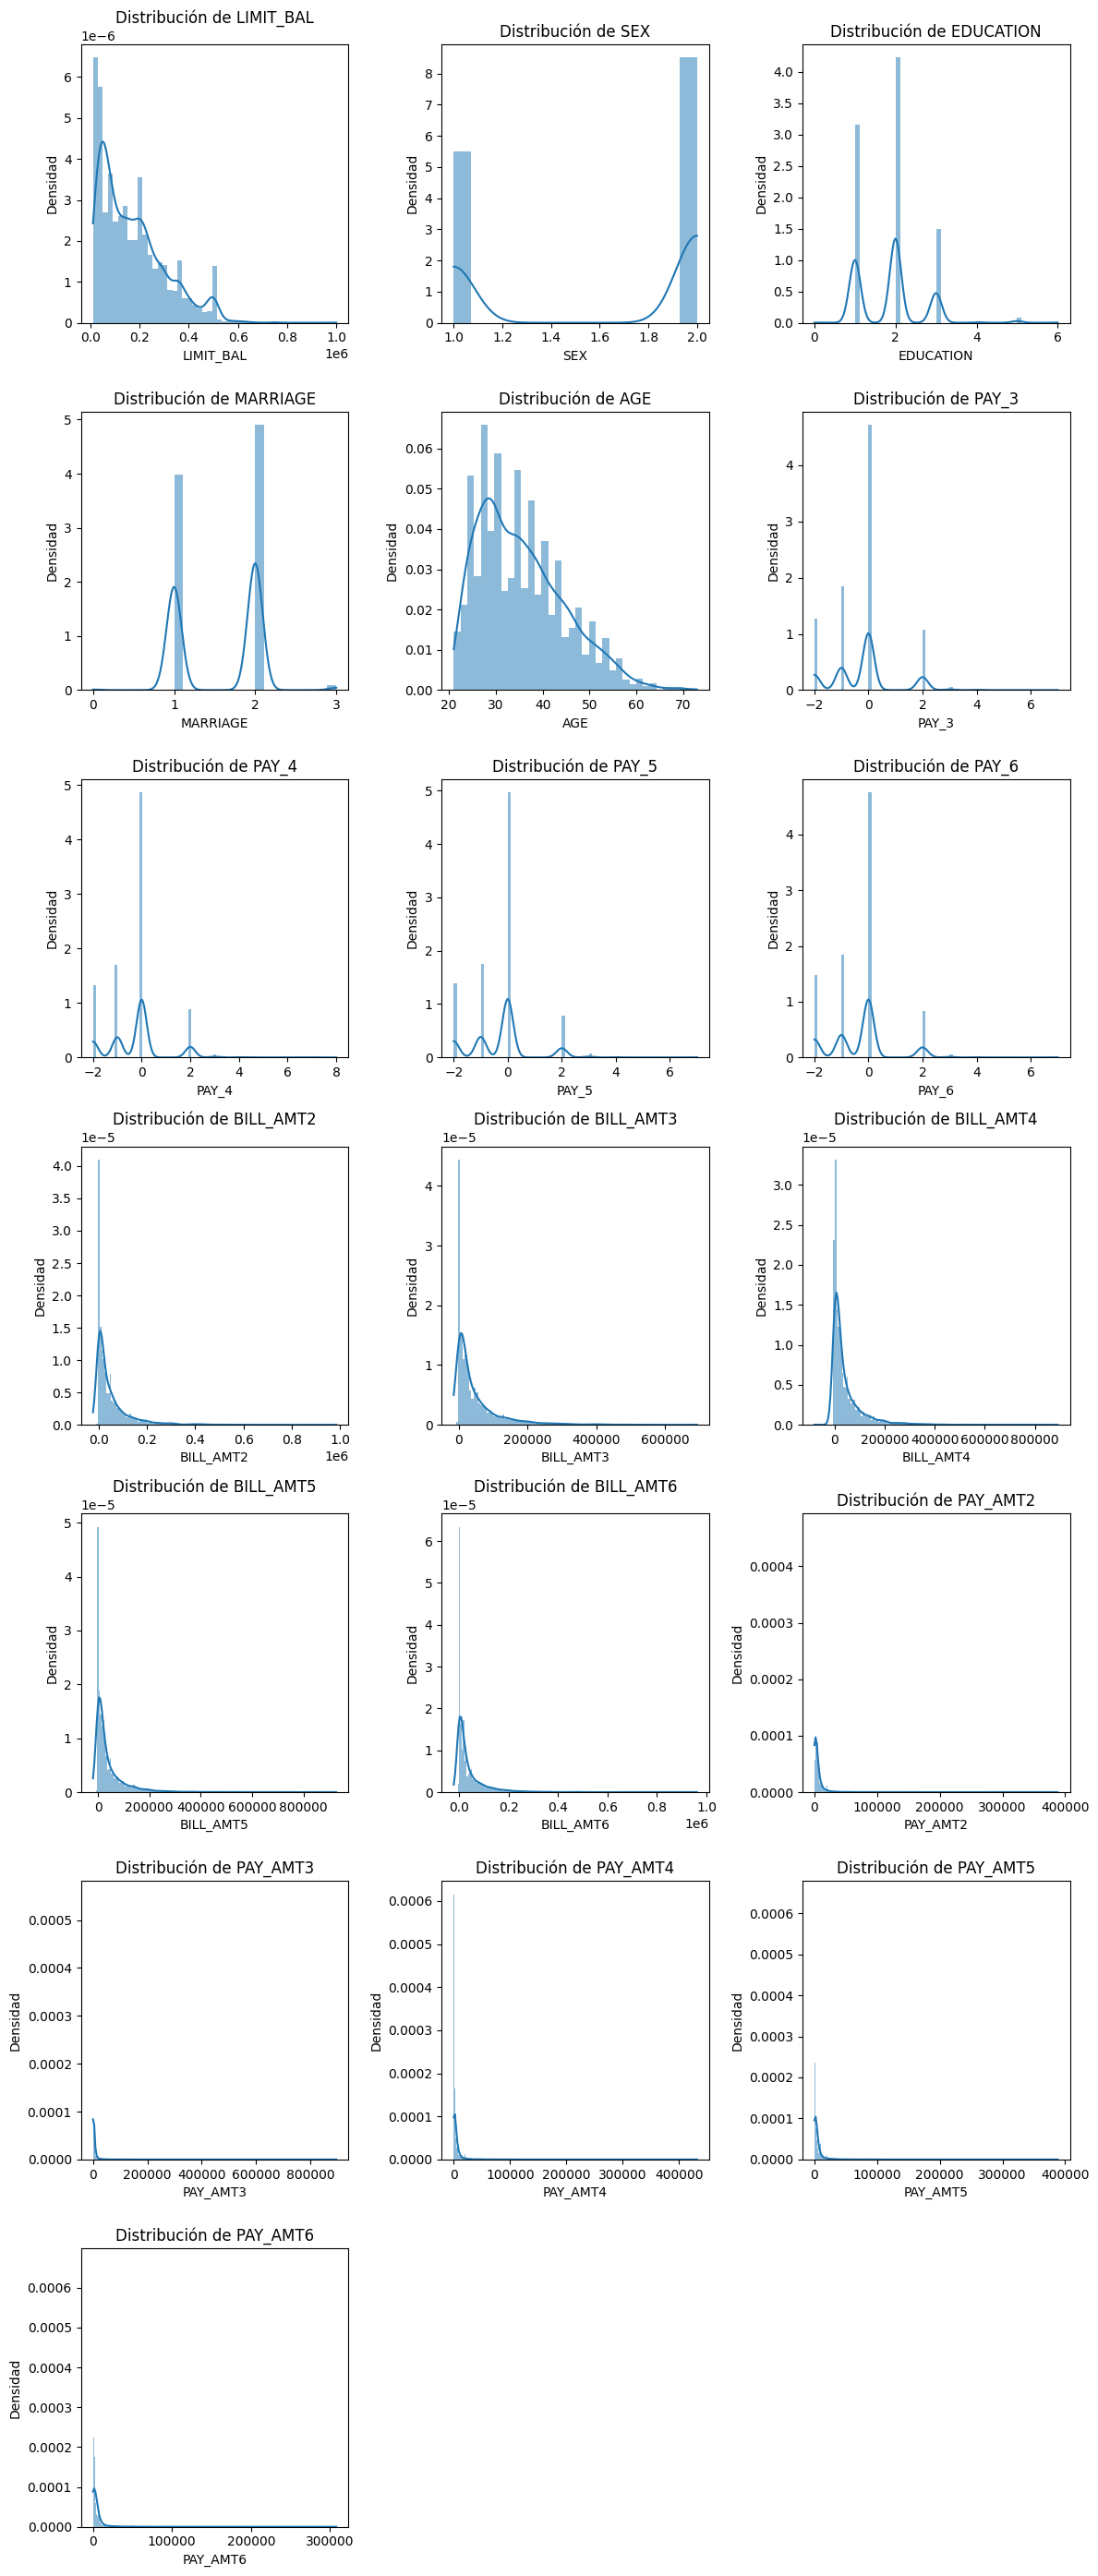

In [55]:
aux = df.drop(columns = 'CUSTOMER_ID')
list_column = aux.columns

num_var = len(list_column)
cols = 3
rows = (num_var // cols) + (num_var % cols > 0)
plt.figure(figsize=(cols * 4, rows * 4))

for i, var in enumerate(list_column, 1):
    plt.subplot(rows, cols, i)  
    sns.histplot(df[var], kde=True, stat="density", linewidth=0)
    plt.plot(linewidth=2)
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Densidad')

plt.tight_layout()
plt.show()

## Ingenieria de variables

In [56]:
X_train, X_test , y_train, y_test = train_test_split(df.drop(columns=['CUSTOMER_ID','PAY_AMT2']), 
                                                     df['PAY_AMT2'], train_size=0.7, random_state=seed)

In [57]:
df = X_train.copy()

In [58]:
df, stats = aplicar_transformaciones(df, stats=None,es_train=True)

In [59]:
df

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Max_Estatus_Pay,Promedio_Estatus_Pay,Ratio_Payment,Count_Pay_Retrasados,Count_Pay_A_Tiempo,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Meses_Pago_Completo,Meses_Deuda,Age_Quartile,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada
1779,130000.0,1,2,2,41,0,0,0,0,106130.0,66523.0,55678.0,20290.0,14802.0,1702.0,602.0,492.0,515.0,1.209946,0,0.00,0.025469,0,0,3311.0,157293.0,0.021050,1187.0,51721.0,153982.0,50534.0,0,4,Adulto,584.755433,827.75,39323.25,648.5,43554.5,42906.0,2680.45,127116.40
1070,50000.0,2,2,1,50,0,0,0,0,20439.0,20691.0,17081.0,16234.0,16330.0,1206.0,1000.0,697.0,532.0,1.406720,0,0.00,0.068700,0,0,3435.0,70336.0,0.048837,674.0,4361.0,66901.0,3687.0,0,4,Mayor,301.917621,858.75,17584.00,488.5,2604.0,2115.5,2613.60,50590.65
3385,260000.0,2,2,2,40,0,0,0,0,244619.0,127074.0,14.0,124493.0,128463.0,0.0,124479.0,6000.0,6500.0,1.461708,0,0.00,0.526842,0,0,136979.0,380044.0,0.360429,-6500.0,-1389.0,243065.0,5111.0,1,3,Adulto,60228.619528,34244.75,95011.00,55989.5,-62934.0,-118923.5,99884.25,259588.65
2705,320000.0,1,1,1,43,0,0,0,0,110045.0,112393.0,111541.0,114934.0,118228.0,5000.0,5000.0,5000.0,5000.0,1.428425,0,0.00,0.062500,0,0,20000.0,457096.0,0.043754,0.0,-5835.0,437096.0,-5835.0,0,4,Mayor,0.000000,5000.00,114274.00,0.0,-4614.0,-4614.0,14000.00,318211.75
4025,120000.0,2,2,2,39,2,0,0,0,24067.0,24372.0,24670.0,25617.0,26535.0,1000.0,1500.0,1500.0,1500.0,0.843283,2,0.50,0.045833,1,0,5500.0,101194.0,0.054351,-500.0,-2163.0,95694.0,-1663.0,0,4,Adulto,250.000000,1375.00,25298.50,-250.0,-1555.0,-1305.0,3700.00,70185.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,50000.0,1,3,2,41,0,0,0,0,14446.0,10339.0,10766.0,10945.0,11214.0,600.0,500.0,600.0,500.0,0.865280,0,0.00,0.044000,0,0,2200.0,43264.0,0.050851,100.0,-875.0,41064.0,-975.0,0,4,Adulto,57.735027,550.00,10816.00,0.0,-527.0,-527.0,1560.00,30026.80
70,50000.0,2,2,1,53,0,0,0,0,36927.0,34929.0,31874.0,28993.0,29409.0,1505.0,1001.0,2007.0,2007.0,2.504100,0,0.00,0.130400,0,0,6520.0,125205.0,0.052075,-502.0,5520.0,118685.0,6022.0,0,4,Mayor,481.499048,1630.00,31301.25,-754.0,4200.5,4954.5,4363.10,89464.35
2878,220000.0,1,2,1,34,0,0,0,0,137465.0,134420.0,132066.0,131319.0,130478.0,5000.0,5000.0,5000.0,10000.0,2.401286,0,0.00,0.113636,0,0,25000.0,528283.0,0.047323,-5000.0,3942.0,503283.0,8942.0,0,4,Adulto joven,2500.000000,6250.00,132070.75,-2500.0,2344.5,4844.5,16250.00,370976.00
1950,200000.0,2,1,2,28,0,0,0,0,8273.0,13249.0,22319.0,17279.0,9853.0,10000.0,5000.0,5000.0,4000.0,0.313500,0,0.00,0.120000,0,0,24000.0,62700.0,0.382775,6000.0,3396.0,38700.0,-2604.0,0,4,Joven,2708.012802,6000.00,15675.00,3000.0,4218.0,1218.0,18550.00,44789.50


In [60]:
X_test = aplicar_transformaciones(X_test, stats=stats, es_train=False)

In [61]:
X_test

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Max_Estatus_Pay,Promedio_Estatus_Pay,Ratio_Payment,Count_Pay_Retrasados,Count_Pay_A_Tiempo,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Meses_Pago_Completo,Meses_Deuda,Age_Quartile,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada
3782,10000.0,1,1,2,22,-1,-1,-1,-1,46.0,915.0,352.0,105.0,0.0,352.0,105.0,0.0,1000.0,0.137200,-1,-1.00,0.145700,0,4,1457.0,1372.0,1.061953,-648.0,915.0,-85.0,1563.0,1,3,Joven,448.782334,364.25,343.00,-271.5,581.0,852.5,880.75,1242.00
4889,50000.0,1,2,2,31,0,0,0,0,45673.0,48833.0,31769.0,9713.0,9521.0,2500.0,500.0,317.0,1000.0,1.996720,0,0.00,0.086340,0,0,4317.0,99836.0,0.043241,1500.0,39312.0,95519.0,37812.0,0,4,Adulto joven,990.179571,1079.25,24959.00,841.5,30684.0,29842.5,3515.20,82772.00
1302,140000.0,2,1,2,28,0,0,0,0,10322.0,12830.0,13317.0,14936.0,18504.0,1000.0,2000.0,4000.0,4000.0,0.425621,0,0.00,0.078571,0,0,11000.0,59587.0,0.184604,-3000.0,-5674.0,48587.0,-2674.0,0,4,Joven,1500.000000,2750.00,14896.75,-2500.0,-3646.5,-1146.5,6700.00,40106.15
313,30000.0,2,3,1,46,0,0,0,0,28544.0,27177.0,28630.0,25087.0,25342.0,2390.0,1000.0,1000.0,2000.0,3.541200,0,0.00,0.213000,0,0,6390.0,106236.0,0.060149,390.0,1835.0,99846.0,1445.0,0,4,Mayor,708.066616,1597.50,26559.00,195.0,2689.0,2494.0,4640.00,75105.60
5138,50000.0,2,3,1,47,-1,-1,-1,0,390.0,1554.0,390.0,780.0,390.0,390.0,780.0,0.0,390.0,0.062280,0,-0.75,0.031200,0,3,1560.0,3114.0,0.500963,0.0,1164.0,1554.0,1164.0,2,3,Mayor,318.433667,390.00,778.50,390.0,387.0,-3.0,1150.50,2490.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5557,500000.0,2,1,2,38,0,0,0,0,74399.0,68761.0,70260.0,70143.0,68506.0,5000.0,5000.0,4000.0,5000.0,0.555340,0,0.00,0.038000,0,0,19000.0,277670.0,0.068427,0.0,255.0,258670.0,255.0,0,4,Adulto,500.000000,4750.00,69417.50,500.0,186.0,-314.0,13400.00,194369.50
2379,490000.0,2,1,1,37,-1,0,0,-1,77996.0,274442.0,233793.0,49461.0,12207.0,4693.0,989.0,12207.0,93707.0,1.163067,0,-0.50,0.227747,0,2,111596.0,569903.0,0.195816,-89014.0,262235.0,458307.0,351249.0,1,3,Adulto,44119.528042,27899.00,142475.75,-50116.0,223283.5,273399.5,54927.10,484956.50
2271,230000.0,1,3,2,29,2,2,2,2,236068.0,236702.0,236309.0,237399.0,229421.0,9000.0,9000.0,0.0,9100.0,4.086222,2,2.00,0.117826,4,0,27100.0,939831.0,0.028835,-100.0,7281.0,912731.0,7381.0,0,4,Adulto joven,4516.912662,6775.00,234957.75,4450.0,3095.5,-1354.5,19845.00,659612.60
5140,340000.0,2,2,2,32,0,0,0,0,82761.0,83636.0,85282.0,87070.0,88828.0,3014.0,3123.0,3168.0,4855.0,1.014165,0,0.00,0.041647,0,0,14160.0,344816.0,0.041065,-1841.0,-5192.0,330656.0,-3351.0,0,4,Adulto joven,879.047591,3540.00,86204.00,-943.0,-3490.0,-2547.0,9441.80,239812.10


In [62]:
X_test.isnull().sum().sum()

np.int64(0)

In [63]:
df.isna().sum().sum()

np.int64(0)

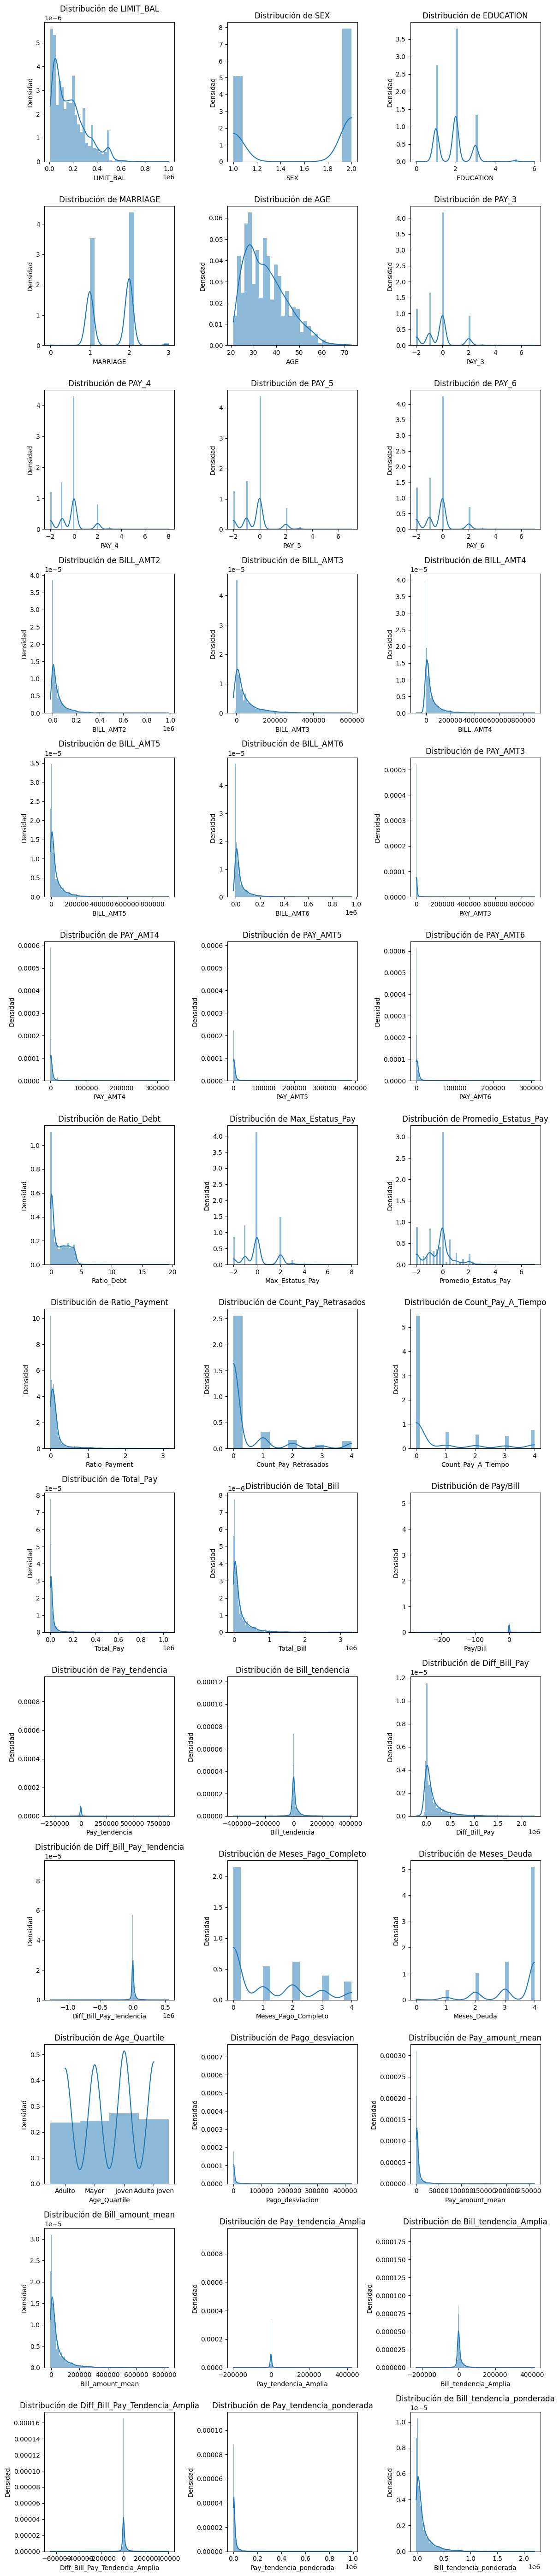

In [64]:
aux = df
list_column = aux.columns

num_var = len(list_column)
cols = 3
rows = (num_var // cols) + (num_var % cols > 0)
plt.figure(figsize=(cols * 4, rows * 4))

for i, var in enumerate(list_column, 1):
    plt.subplot(rows, cols, i)  
    sns.histplot(df[var], kde=True, stat="density", linewidth=0)
    plt.plot(linewidth=2)
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Densidad')

plt.tight_layout()
plt.show()

In [65]:
lst_column_log = ['LIMIT_BAL','AGE','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
                  'PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6','Ratio_Debt','Ratio_Payment','Total_Pay','Total_Bill',
                  'Pay_amount_mean','Bill_amount_mean','Diff_Bill_Pay','Pay_tendencia_ponderada','Bill_tendencia_ponderada','Pago_desviacion']

In [66]:
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_3', 'PAY_4',
       'PAY_5', 'PAY_6', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5',
       'BILL_AMT6', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'Ratio_Debt', 'Max_Estatus_Pay', 'Promedio_Estatus_Pay',
       'Ratio_Payment', 'Count_Pay_Retrasados', 'Count_Pay_A_Tiempo',
       'Total_Pay', 'Total_Bill', 'Pay/Bill', 'Pay_tendencia',
       'Bill_tendencia', 'Diff_Bill_Pay', 'Diff_Bill_Pay_Tendencia',
       'Meses_Pago_Completo', 'Meses_Deuda', 'Age_Quartile', 'Pago_desviacion',
       'Pay_amount_mean', 'Bill_amount_mean', 'Pay_tendencia_Amplia',
       'Bill_tendencia_Amplia', 'Diff_Bill_Pay_Tendencia_Amplia',
       'Pay_tendencia_ponderada', 'Bill_tendencia_ponderada'],
      dtype='object')

In [67]:
lst_column_log

['LIMIT_BAL',
 'AGE',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'Ratio_Debt',
 'Ratio_Payment',
 'Total_Pay',
 'Total_Bill',
 'Pay_amount_mean',
 'Bill_amount_mean',
 'Diff_Bill_Pay',
 'Pay_tendencia_ponderada',
 'Bill_tendencia_ponderada',
 'Pago_desviacion']

In [68]:
for col in lst_column_log:
    offset = abs(df[col].min()) + 1
    df[f'{col}_log'] = np.log1p(np.maximum(df[col] + offset,0))
    X_test[f'{col}_log'] = np.log1p(np.maximum(X_test[col] + offset,0))

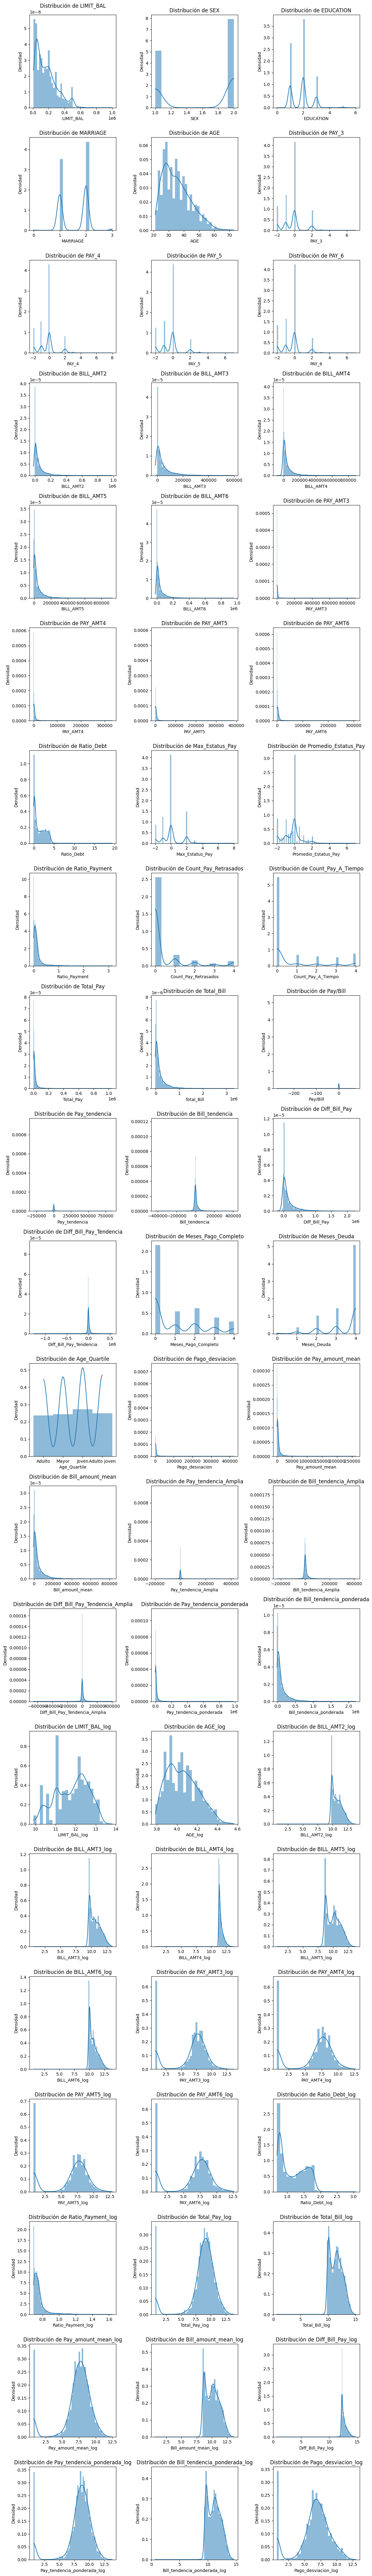

In [69]:
aux = df
list_column = aux.columns

num_var = len(list_column)
cols = 3
rows = (num_var // cols) + (num_var % cols > 0)
plt.figure(figsize=(cols * 4, rows * 4))

for i, var in enumerate(list_column, 1):
    plt.subplot(rows, cols, i)  
    sns.histplot(df[var], kde=True, stat="density", linewidth=0)
    plt.plot(linewidth=2)
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Densidad')

plt.tight_layout()
plt.show()

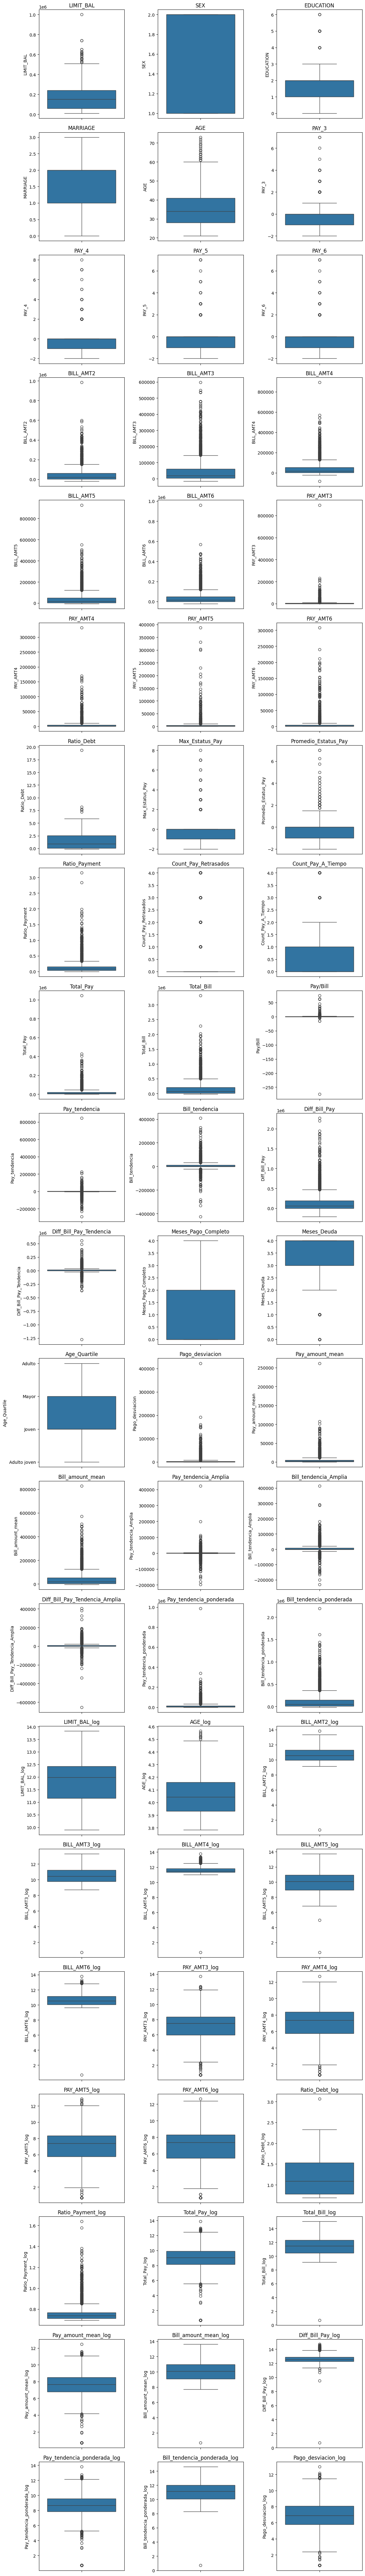

In [70]:
aux = df
list_column = aux.columns

num_var = len(list_column)
cols = 3
rows = (num_var // cols) + (num_var % cols > 0)
plt.figure(figsize=(cols * 4, rows * 4))

for i, var in enumerate(list_column, 1):
    plt.subplot(rows, cols, i) 
    sns.boxplot(y=df[var])  
    plt.title(var)  
plt.tight_layout()  
plt.show()


In [71]:
df.isnull().sum().sum()

np.int64(0)

In [72]:
X_test.isnull().sum().sum()

np.int64(0)

In [73]:
df.describe([0.01,0.05, 0.25, 0.5, 0.75, 0.95 ,0.99])

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Max_Estatus_Pay,Promedio_Estatus_Pay,Ratio_Payment,Count_Pay_Retrasados,Count_Pay_A_Tiempo,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Meses_Pago_Completo,Meses_Deuda,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada,LIMIT_BAL_log,AGE_log,BILL_AMT2_log,BILL_AMT3_log,BILL_AMT4_log,BILL_AMT5_log,BILL_AMT6_log,PAY_AMT3_log,PAY_AMT4_log,PAY_AMT5_log,PAY_AMT6_log,Ratio_Debt_log,Ratio_Payment_log,Total_Pay_log,Total_Bill_log,Pay_amount_mean_log,Bill_amount_mean_log,Diff_Bill_Pay_log,Pay_tendencia_ponderada_log,Bill_tendencia_ponderada_log,Pago_desviacion_log
count,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.00000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.00000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3.937000e+03,3.937000e+03,3937.000000,3937.000000,3937.000000,3.937000e+03,3.937000e+03,3937.00000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3.937000e+03,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000
mean,171356.362713,1.608585,1.853442,1.563881,35.377191,-0.224790,-0.24765,-0.293371,-0.322327,49139.175006,46551.623317,42651.529591,39656.95555,38675.909322,5086.082550,4782.217170,4923.792990,5233.556007,1.370504,0.090932,-0.272035,0.140473,0.438913,0.801372,2.002565e+04,1.675360e+05,0.460156,-147.473457,7875.713995,1.475104e+05,8.023187e+03,1.03683,3.392939,4972.222781,5006.412179,41884.004445,-144.524638,5435.144018,5579.668656,13982.121425,1.197386e+05,11.812224,4.055109,10.724092,10.603477,11.636752,10.073619,10.690024,6.421294,6.270666,6.251491,6.198585,1.167074,0.757221,8.570746,11.501931,7.287307,10.116091,12.654220,8.245537,11.149250,6.597616
std,131028.565649,0.488129,0.767154,0.519973,9.190714,1.158661,1.15443,1.125074,1.129785,72762.793530,68935.309421,66091.269618,62148.30061,62117.790531,19511.369207,13082.343519,16327.931548,16409.060781,1.403983,1.295851,1.022008,0.207943,1.005013,1.351064,3.889445e+04,2.511672e+05,5.145358,23706.344495,34519.173962,2.408429e+05,4.645317e+04,1.32457,0.924366,14553.721720,9723.613465,62791.801499,15753.898702,24005.219426,29973.904390,29039.631410,1.783125e+05,0.820756,0.152180,0.841041,0.882388,0.420245,1.137188,0.735224,3.069639,3.133671,3.158774,3.196251,0.383562,0.083047,2.523759,1.138809,2.212854,1.135592,0.515432,2.438646,1.153642,2.470321
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.00000,-2.000000,-2.000000,-17810.000000,-14998.000000,-81334.000000,-5960.00000,-21364.000000,0.000000,0.000000,0.000000,0.000000,-0.094909,-2.000000,-2.000000,0.000000,0.000000,0.000000,0.000000e+00,-2.088000e+04,-274.619048,-292882.000000,-426644.000000,-2.128020e+05,-1.272428e+06,0.00000,0.000000,0.000000,0.000000,-5220.000000,-197747.500000,-231114.500000,-654006.500000,0.000000,-1.419600e+04,9.903588,3.784190,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147
1%,10000.000000,1.000000,1.000000,1.000000,22.000000,-2.000000,-2.00000,-2.000000,-2.000000,-200.000000,-167.040000,-225.040000,-244.28000,-328.840000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.000000,-2.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,-74664.800000,-76590.520000,-3.723904e+04,-1.057408e+05,0.00000,1.000000,0.000000,0.000000,0.000000,-514

### Outiliers

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3937 entries, 1779 to 1922
Data columns (total 63 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   LIMIT_BAL                       3937 non-null   float64
 1   SEX                             3937 non-null   int64  
 2   EDUCATION                       3937 non-null   int64  
 3   MARRIAGE                        3937 non-null   int64  
 4   AGE                             3937 non-null   int64  
 5   PAY_3                           3937 non-null   int64  
 6   PAY_4                           3937 non-null   int64  
 7   PAY_5                           3937 non-null   int64  
 8   PAY_6                           3937 non-null   int64  
 9   BILL_AMT2                       3937 non-null   float64
 10  BILL_AMT3                       3937 non-null   float64
 11  BILL_AMT4                       3937 non-null   float64
 12  BILL_AMT5                       3937

In [77]:
lst_out_upper = ['BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6','Pago_desviacion',
               'PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6','Promedio_Estatus_Pay','Ratio_Payment','Total_Pay', 'Total_Bill',
                 'Pay/Bill','Pay_amount_mean','Bill_amount_mean','Diff_Bill_Pay','Ratio_Payment_log','Pay_tendencia_ponderada','Bill_tendencia_ponderada']
lst_out_both = ['Pay/Bill','Pay_tendencia','Bill_tendencia','Pay_tendencia_Amplia','Bill_tendencia_Amplia','Diff_Bill_Pay_Tendencia',
                'Diff_Bill_Pay_Tendencia_Amplia','BILL_AMT2_log','BILL_AMT3_log','BILL_AMT4_log','BILL_AMT5_log','Pago_desviacion_log',
                'BILL_AMT6_log','PAY_AMT3_log','PAY_AMT4_log','PAY_AMT5_log','Total_Pay_log','Diff_Bill_Pay_log','Pay_tendencia_ponderada_log']
lst_out_lower = ['Total_Bill_log','Bill_amount_mean_log','Bill_tendencia_ponderada_log']

In [78]:
for v in lst_out_upper: # Debido a la gran cantidad de outliers vistos en los boxplot, aplicamos winsorize parta no perder tantos datos
    df[v] = winsorize(df[v], limits = [0, 0.1])

for v in lst_out_both:
    df[v] = winsorize(df[v], limits = [0.05, 0.05])

for v in lst_out_lower:
    df[v] = winsorize(df[v], limits = [0.1, 0])


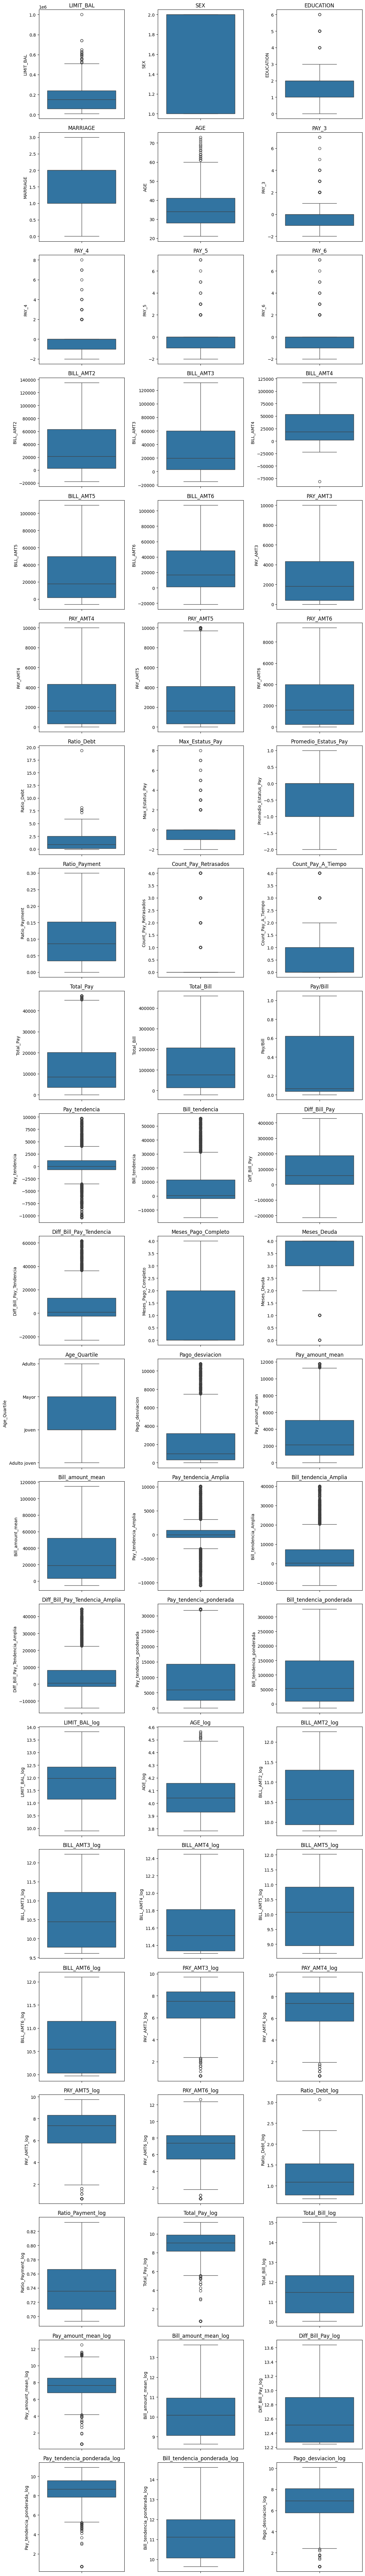

In [79]:
aux = df
list_column = aux.columns

num_var = len(list_column)
cols = 3
rows = (num_var // cols) + (num_var % cols > 0)
plt.figure(figsize=(cols * 4, rows * 4))

for i, var in enumerate(list_column, 1):
    plt.subplot(rows, cols, i)  
    sns.boxplot(y=df[var])  
    plt.title(var)  
plt.tight_layout()  
plt.show()

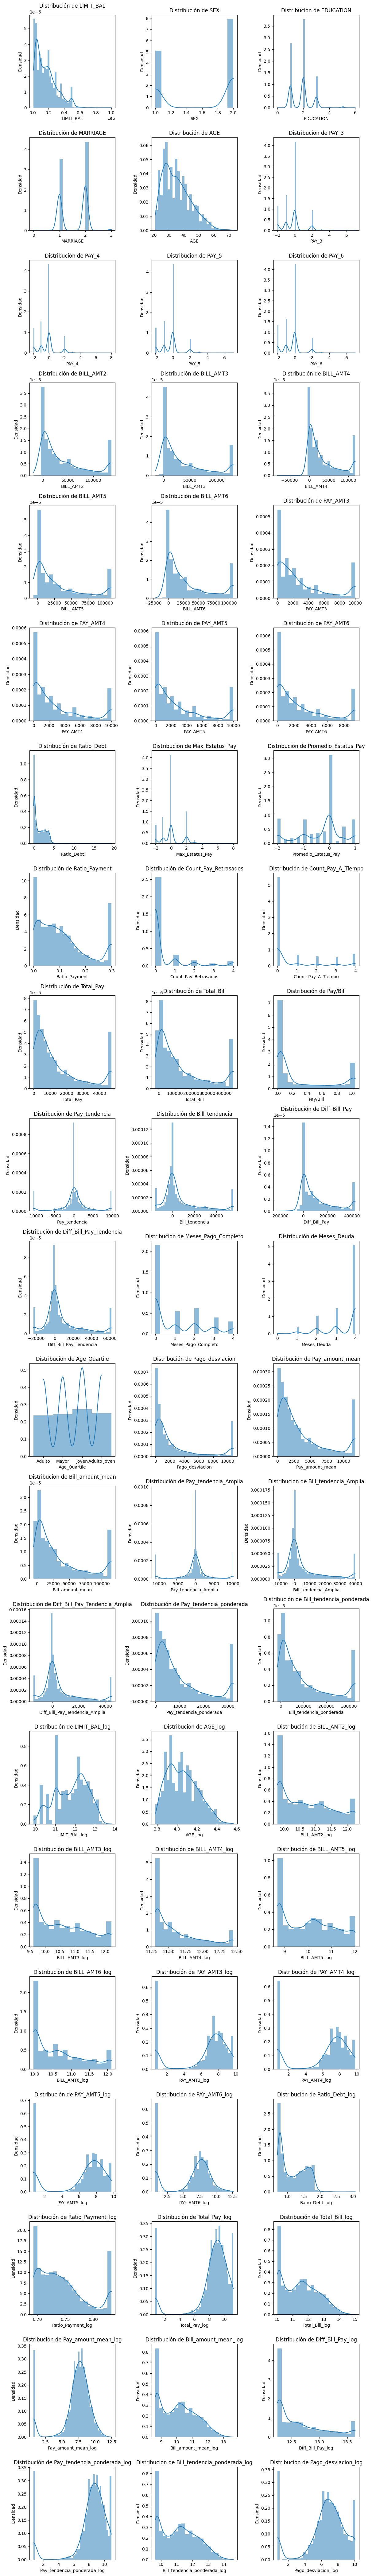

In [80]:
aux = df
list_column = aux.columns

num_var = len(list_column)
cols = 3
rows = (num_var // cols) + (num_var % cols > 0)
plt.figure(figsize=(cols * 4, rows * 4))

for i, var in enumerate(list_column, 1):
    plt.subplot(rows, cols, i)  
    sns.histplot(df[var], kde=True, stat="density", linewidth=0)
    plt.plot(linewidth=2)
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Densidad')

plt.tight_layout()
plt.show()

### Codificacion

In [81]:
df

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Max_Estatus_Pay,Promedio_Estatus_Pay,Ratio_Payment,Count_Pay_Retrasados,Count_Pay_A_Tiempo,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Meses_Pago_Completo,Meses_Deuda,Age_Quartile,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada,LIMIT_BAL_log,AGE_log,BILL_AMT2_log,BILL_AMT3_log,BILL_AMT4_log,BILL_AMT5_log,BILL_AMT6_log,PAY_AMT3_log,PAY_AMT4_log,PAY_AMT5_log,PAY_AMT6_log,Ratio_Debt_log,Ratio_Payment_log,Total_Pay_log,Total_Bill_log,Pay_amount_mean_log,Bill_amount_mean_log,Diff_Bill_Pay_log,Pay_tendencia_ponderada_log,Bill_tendencia_ponderada_log,Pago_desviacion_log
1779,130000.0,1,2,2,41,0,0,0,0,106130.0,66523.0,55678.0,20290.0,14802.0,1702.0,602.0,492.0,515.0,1.209946,0,0.00,0.025469,0,0,3311.0,157293.0,0.021050,1187.0,51721.0,153982.0,50534.0,0,4,Adulto,584.755433,827.75,39323.25,648.5,39888.0,42906.0,2680.45,127116.40,11.849412,4.158883,11.727569,11.308640,11.827838,10.175497,10.495930,7.440734,6.403574,6.202536,6.248043,1.195393,0.705801,8.105609,12.090521,6.721124,10.704261,12.812534,7.894486,11.858742,6.374608
1070,50000.0,2,2,1,50,0,0,0,0,20439.0,20691.0,17081.0,16234.0,16330.0,1206.0,1000.0,697.0,532.0,1.406720,0,0.00,0.068700,0,0,3435.0,70336.0,0.048837,674.0,4361.0,66901.0,3687.0,0,4,Mayor,301.917621,858.75,17584.00,488.5,2604.0,2115.5,2613.60,50590.65,11.002133,4.290459,10.551925,10.482654,11.496969,10.007667,10.537309,7.096721,6.909753,6.549651,6.280396,1.253228,0.726920,8.142354,11.421008,6.757804,10.034779,12.541491,7.869249,11.078886,5.716757
3385,260000.0,2,2,2,40,0,0,0,0,135476.0,127074.0,14.0,109293.0,107209.0,0.0,10000.0,6000.0,6500.0,1.461708,0,0.00,0.299755,0,0,47119.0,380044.0,0.360429,-6500.0,-1389.0,243065.0,5111.0,1,3,Adulto,10787.209633,11779.75,95011.00,10109.5,-11260.0,-14143.5,32205.10,259588.65,12.506185,4.143135,12.259476,11.864103,11.306516,11.778784,11.917250,0.693147,9.816294,8.699848,8.779865,1.268810,0.832802,11.249936,12.901532,10.441347,11.515253,13.029961,10.913305,12.520104,10.077335
2705,320000.0,1,1,1,43,0,0,0,0,110045.0,112393.0,111541.0,109293.0,107209.0,5000.0,5000.0,5000.0,5000.0,1.428425,0,0.00,0.062500,0,0,20000.0,457096.0,0.043754,0.0,-5835.0,428103.0,-5835.0,0,4,Mayor,0.000000,5000.00,114274.00,0.0,-4614.0,-4614.0,14000.00,318211.75,12.706854,4.189655,11.758668,11.755032,12.169808,11.702686,11.846493,8.517593,8.517593,8.517593,8.517593,1.259408,0.723919,9.903588,13.077320,8.517593,11.691038,13.384574,9.546955,12.714124,0.693147
4025,120000.0,2,2,2,39,2,0,0,0,24067.0,24372.0,24670.0,25617.0,26535.0,1000.0,1500.0,1500.0,1500.0,0.843283,2,0.50,0.045833,1,0,5500.0,101194.0,0.054351,-500.0,-2163.0,95694.0,-1663.0,0,4,Adulto,250.000000,1375.00,25298.50,-250.0,-1555.0,-1305.0,3700.00,70185.45,11.775305,4.127134,10.642540,10.580810,11.571251,10.360248,10.776892,6.909753,7.314553,7.314553,7.314553,1.077795,0.715805,8.612867,11.712399,7.227662,10.326154,12.639471,8.216628,11.343127,5.529429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,50000.0,1,3,2,41,0,0,0,0,14446.0,10339.0,10766.0,10945.0,11214.0,600.0,500.0,600.0,500.0,0.865280,0,0.00,0.044000,0,0,2200.0,43264.0,0.050851,100.0,-875.0,41064.0,-975.0,0,4,Adulto,57.735027,550.00,10816.00,0.0,-527.0,-527.0,1560.00,30026.80,11.002133,4.158883,10.381521,10.140100,11.430652,9.735483,10.391454,6.400257,6.218600,6.400257,6.218600,1.085253,0.714909,7.697121,11.068917,6.313548,9.682716,12.444570,7.353722,10.697041,4.089919
70,50000.0,2,2,1,53,0,0,0,0,36927.0,34929.0,31874.0,28993.0,29409.0,1505.0,1001.0,20

In [82]:
X_test

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Max_Estatus_Pay,Promedio_Estatus_Pay,Ratio_Payment,Count_Pay_Retrasados,Count_Pay_A_Tiempo,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Meses_Pago_Completo,Meses_Deuda,Age_Quartile,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada,LIMIT_BAL_log,AGE_log,BILL_AMT2_log,BILL_AMT3_log,BILL_AMT4_log,BILL_AMT5_log,BILL_AMT6_log,PAY_AMT3_log,PAY_AMT4_log,PAY_AMT5_log,PAY_AMT6_log,Ratio_Debt_log,Ratio_Payment_log,Total_Pay_log,Total_Bill_log,Pay_amount_mean_log,Bill_amount_mean_log,Diff_Bill_Pay_log,Pay_tendencia_ponderada_log,Bill_tendencia_ponderada_log,Pago_desviacion_log
3782,10000.0,1,1,2,22,-1,-1,-1,-1,46.0,915.0,352.0,105.0,0.0,352.0,105.0,0.0,1000.0,0.137200,-1,-1.00,0.145700,0,4,1457.0,1372.0,1.061953,-648.0,915.0,-85.0,1563.0,1,3,Joven,448.782334,364.25,343.00,-271.5,581.0,852.5,880.75,1242.00,9.903588,3.806662,9.790207,9.675017,11.310662,8.710620,9.969556,5.869297,4.672829,0.693147,6.909753,0.802947,0.763466,7.285507,10.010277,5.903316,8.624252,12.267727,6.783042,9.644717,6.110985
4889,50000.0,1,2,2,31,0,0,0,0,45673.0,48833.0,31769.0,9713.0,9521.0,2500.0,500.0,317.0,1000.0,1.996720,0,0.00,0.086340,0,0,4317.0,99836.0,0.043241,1500.0,39312.0,95519.0,37812.0,0,4,Adulto joven,990.179571,1079.25,24959.00,841.5,30684.0,29842.5,3515.20,82772.00,11.002133,3.988984,11.058559,11.064026,11.636072,9.659822,10.338091,7.824846,6.218600,5.765191,6.909753,1.408943,0.735411,8.370779,11.701213,6.985873,10.314968,12.638903,8.165420,11.482157,6.899904
1302,140000.0,2,1,2,28,0,0,0,0,10322.0,12830.0,13317.0,14936.0,18504.0,1000.0,2000.0,4000.0,4000.0,0.425621,0,0.00,0.078571,0,0,11000.0,59587.0,0.184604,-3000.0,-5674.0,48587.0,-2674.0,0,4,Joven,1500.000000,2750.00,14896.75,-2500.0,-3646.5,-1146.5,6700.00,40106.15,11.918404,3.931826,10.244734,10.233870,11.457973,9.947409,10.593379,6.909753,7.601902,8.294550,8.294550,0.924469,0.731681,9.305832,11.295627,7.920083,9.909407,12.473773,8.810161,10.902356,7.314553
313,30000.0,2,3,1,46,0,0,0,0,28544.0,27177.0,28630.0,25087.0,25342.0,2390.0,1000.0,1000.0,2000.0,3.541200,0,0.00,0.213000,0,0,6390.0,106236.0,0.060149,390.0,1835.0,99846.0,1445.0,0,4,Mayor,708.066616,1597.50,26559.00,195.0,2689.0,2494.0,4640.00,75105.60,10.596685,4.234107,10.744106,10.649630,11.607927,10.343322,10.751671,7.779885,6.909753,6.909753,7.601902,1.729194,0.794349,8.762802,11.752871,7.377446,10.366624,12.652840,8.442901,11.399797,6.565359
5138,50000.0,2,3,1,47,-1,-1,-1,0,390.0,1554.0,390.0,780.0,390.0,390.0,780.0,0.0,390.0,0.062280,0,-0.75,0.031200,0,3,1560.0,3114.0,0.500963,0.0,1164.0,1554.0,1164.0,2,3,Mayor,318.433667,390.00,778.50,390.0,387.0,-3.0,1150.50,2490.00,11.002133,4.248495,9.809287,9.714383,11.311127,8.816112,9.987645,5.971262,6.661855,0.693147,5.971262,0.768806,0.708627,7.353722,10.085642,5.971262,8.699598,12.275403,7.049689,9.722445,5.769675
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5557,500000.0,2,1,2,38,0,0,0,0,74399.0,68761.0,70260.0,70143.0,68506.0,5000.0,5000.0,4000.0,5000.0,0.555340,0,0.00,0.038000,0,0,19000.0,277670.0,0.068427,0.0,255.0,258670.0,255.0,0,4,Adulto,500.000000,4750.00,69417.50,500.0,186.0,-314.0,13400.00,194369.50,13.142170,4.110874,11.431835,11.335723,11.928974,11.239869,11.406142,8.517593,8.517593,8.294550,8.517593,0.974654,0.711969,9.852300,12.606699,8.466321,11.220425,13.063619,9.503159,12.248018,6.218600
2379,490000.0,2,1,1,37,-1,0,0,-1,77996.0,274442.0,233793.0,49461.0,12207.0,4693.0,989.0,12207.0,93707.0,1.163067,0,-0.50,0.227747,0,2,111596.0,569903.0,0.1958

In [83]:
df['Age_Quartile'].unique()

array(['Adulto', 'Mayor', 'Joven', 'Adulto joven'], dtype=object)

In [84]:
df = pd.get_dummies(df, columns = ['EDUCATION'],prefix='EDUCATION') # Codificamos las variables para el modelo
df = pd.get_dummies(df, columns = ['MARRIAGE'],prefix='MARRIAGE')
df = pd.get_dummies(df, columns = ['SEX'],prefix='SEX')
mapeo_Age = {'Joven':1, 'Adulto joven' :2, 'Adulto':3, 'Mayor':4}
df['Age_Quartile'] = df['Age_Quartile'].map(mapeo_Age)
X_test = pd.get_dummies(X_test, columns = ['EDUCATION'],prefix='EDUCATION') # Codificamos las variables para el modelo
X_test = pd.get_dummies(X_test, columns = ['MARRIAGE'],prefix='MARRIAGE')
X_test = pd.get_dummies(X_test, columns = ['SEX'],prefix='SEX')
X_test['Age_Quartile'] = X_test['Age_Quartile'].map(mapeo_Age)

In [85]:
df

,LIMIT_BAL,AGE,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Max_Estatus_Pay,Promedio_Estatus_Pay,Ratio_Payment,Count_Pay_Retrasados,Count_Pay_A_Tiempo,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Meses_Pago_Completo,Meses_Deuda,Age_Quartile,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada,LIMIT_BAL_log,AGE_log,BILL_AMT2_log,BILL_AMT3_log,BILL_AMT4_log,BILL_AMT5_log,BILL_AMT6_log,PAY_AMT3_log,PAY_AMT4_log,PAY_AMT5_log,PAY_AMT6_log,Ratio_Debt_log,Ratio_Payment_log,Total_Pay_log,Total_Bill_log,Pay_amount_mean_log,Bill_amount_mean_log,Diff_Bill_Pay_log,Pay_tendencia_ponderada_log,Bill_tendencia_ponderada_log,Pago_desviacion_log,EDUCATION_0,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6,MARRIAGE_0,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3,SEX_1,SEX_2
1779,130000.0,41,0,0,0,0,106130.0,66523.0,55678.0,20290.0,14802.0,1702.0,602.0,492.0,515.0,1.209946,0,0.00,0.025469,0,0,3311.0,157293.0,0.021050,1187.0,51721.0,153982.0,50534.0,0,4,3,584.755433,827.75,39323.25,648.5,39888.0,42906.0,2680.45,127116.40,11.849412,4.158883,11.727569,11.308640,11.827838,10.175497,10.495930,7.440734,6.403574,6.202536,6.248043,1.195393,0.705801,8.105609,12.090521,6.721124,10.704261,12.812534,7.894486,11.858742,6.374608,False,False,True,False,False,False,False,False,False,True,False,True,False
1070,50000.0,50,0,0,0,0,20439.0,20691.0,17081.0,16234.0,16330.0,1206.0,1000.0,697.0,532.0,1.406720,0,0.00,0.068700,0,0,3435.0,70336.0,0.048837,674.0,4361.0,66901.0,3687.0,0,4,4,301.917621,858.75,17584.00,488.5,2604.0,2115.5,2613.60,50590.65,11.002133,4.290459,10.551925,10.482654,11.496969,10.007667,10.537309,7.096721,6.909753,6.549651,6.280396,1.253228,0.726920,8.142354,11.421008,6.757804,10.034779,12.541491,7.869249,11.078886,5.716757,False,False,True,False,False,False,False,False,True,False,False,False,True
3385,260000.0,40,0,0,0,0,135476.0,127074.0,14.0,109293.0,107209.0,0.0,10000.0,6000.0,6500.0,1.461708,0,0.00,0.299755,0,0,47119.0,380044.0,0.360429,-6500.0,-1389.0,243065.0,5111.0,1,3,3,10787.209633,11779.75,95011.00,10109.5,-11260.0,-14143.5,32205.10,259588.65,12.506185,4.143135,12.259476,11.864103,11.306516,11.778784,11.917250,0.693147,9.816294,8.699848,8.779865,1.268810,0.832802,11.249936,12.901532,10.441347,11.515253,13.029961,10.913305,12.520104,10.077335,False,False,True,False,False,False,False,False,False,True,False,False,True
2705,320000.0,43,0,0,0,0,110045.0,112393.0,111541.0,109293.0,107209.0,5000.0,5000.0,5000.0,5000.0,1.428425,0,0.00,0.062500,0,0,20000.0,457096.0,0.043754,0.0,-5835.0,428103.0,-5835.0,0,4,4,0.000000,5000.00,114274.00,0.0,-4614.0,-4614.0,14000.00,318211.75,12.706854,4.189655,11.758668,11.755032,12.169808,11.702686,11.846493,8.517593,8.517593,8.517593,8.517593,1.259408,0.723919,9.903588,13.077320,8.517593,11.691038,13.384574,9.546955,12.714124,0.693147,False,True,False,False,False,False,False,False,True,False,False,True,False
4025,120000.0,39,2,0,0,0,24067.0,24372.0,24670.0,25617.0,26535.0,1000.0,1500.0,1500.0,1500.0,0.843283,2,0.50,0.045833,1,0,5500.0,101194.0,0.054351,-500.0,-2163.0,95694.0,-1663.0,0,4,3,250.000000,1375.00,25298.50,-250.0,-1555.0,-1305.0,3700.00,70185.45,11.775305,4.127134,10.642540,10.580810,11.571251,10.360248,10.776892,6.909753,7.314553,7.314553,7.314553,1.077795,0.715805,8.612867,11.712399,7.227662,10.326154,12.639471,8.216628,11.343127,5.529429,False,False,True,False,False,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,50000.0,41,0,0,0,0,14446.0,10339.0,10766.0,1

In [86]:
X_test = X_test.reindex(columns=df.columns, fill_value= False)

In [87]:
X_test

,LIMIT_BAL,AGE,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Max_Estatus_Pay,Promedio_Estatus_Pay,Ratio_Payment,Count_Pay_Retrasados,Count_Pay_A_Tiempo,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Meses_Pago_Completo,Meses_Deuda,Age_Quartile,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada,LIMIT_BAL_log,AGE_log,BILL_AMT2_log,BILL_AMT3_log,BILL_AMT4_log,BILL_AMT5_log,BILL_AMT6_log,PAY_AMT3_log,PAY_AMT4_log,PAY_AMT5_log,PAY_AMT6_log,Ratio_Debt_log,Ratio_Payment_log,Total_Pay_log,Total_Bill_log,Pay_amount_mean_log,Bill_amount_mean_log,Diff_Bill_Pay_log,Pay_tendencia_ponderada_log,Bill_tendencia_ponderada_log,Pago_desviacion_log,EDUCATION_0,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6,MARRIAGE_0,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3,SEX_1,SEX_2
3782,10000.0,22,-1,-1,-1,-1,46.0,915.0,352.0,105.0,0.0,352.0,105.0,0.0,1000.0,0.137200,-1,-1.00,0.145700,0,4,1457.0,1372.0,1.061953,-648.0,915.0,-85.0,1563.0,1,3,1,448.782334,364.25,343.00,-271.5,581.0,852.5,880.75,1242.00,9.903588,3.806662,9.790207,9.675017,11.310662,8.710620,9.969556,5.869297,4.672829,0.693147,6.909753,0.802947,0.763466,7.285507,10.010277,5.903316,8.624252,12.267727,6.783042,9.644717,6.110985,False,True,False,False,False,False,False,False,False,True,False,True,False
4889,50000.0,31,0,0,0,0,45673.0,48833.0,31769.0,9713.0,9521.0,2500.0,500.0,317.0,1000.0,1.996720,0,0.00,0.086340,0,0,4317.0,99836.0,0.043241,1500.0,39312.0,95519.0,37812.0,0,4,2,990.179571,1079.25,24959.00,841.5,30684.0,29842.5,3515.20,82772.00,11.002133,3.988984,11.058559,11.064026,11.636072,9.659822,10.338091,7.824846,6.218600,5.765191,6.909753,1.408943,0.735411,8.370779,11.701213,6.985873,10.314968,12.638903,8.165420,11.482157,6.899904,False,False,True,False,False,False,False,False,False,True,False,True,False
1302,140000.0,28,0,0,0,0,10322.0,12830.0,13317.0,14936.0,18504.0,1000.0,2000.0,4000.0,4000.0,0.425621,0,0.00,0.078571,0,0,11000.0,59587.0,0.184604,-3000.0,-5674.0,48587.0,-2674.0,0,4,1,1500.000000,2750.00,14896.75,-2500.0,-3646.5,-1146.5,6700.00,40106.15,11.918404,3.931826,10.244734,10.233870,11.457973,9.947409,10.593379,6.909753,7.601902,8.294550,8.294550,0.924469,0.731681,9.305832,11.295627,7.920083,9.909407,12.473773,8.810161,10.902356,7.314553,False,True,False,False,False,False,False,False,False,True,False,False,True
313,30000.0,46,0,0,0,0,28544.0,27177.0,28630.0,25087.0,25342.0,2390.0,1000.0,1000.0,2000.0,3.541200,0,0.00,0.213000,0,0,6390.0,106236.0,0.060149,390.0,1835.0,99846.0,1445.0,0,4,4,708.066616,1597.50,26559.00,195.0,2689.0,2494.0,4640.00,75105.60,10.596685,4.234107,10.744106,10.649630,11.607927,10.343322,10.751671,7.779885,6.909753,6.909753,7.601902,1.729194,0.794349,8.762802,11.752871,7.377446,10.366624,12.652840,8.442901,11.399797,6.565359,False,False,False,True,False,False,False,False,True,False,False,False,True
5138,50000.0,47,-1,-1,-1,0,390.0,1554.0,390.0,780.0,390.0,390.0,780.0,0.0,390.0,0.062280,0,-0.75,0.031200,0,3,1560.0,3114.0,0.500963,0.0,1164.0,1554.0,1164.0,2,3,4,318.433667,390.00,778.50,390.0,387.0,-3.0,1150.50,2490.00,11.002133,4.248495,9.809287,9.714383,11.311127,8.816112,9.987645,5.971262,6.661855,0.693147,5.971262,0.768806,0.708627,7.353722,10.085642,5.971262,8.699598,12.275403,7.049689,9.722445,5.769675,False,False,False,True,False,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5557,500000.0,38,0,0,0,0,74399.0,68761.0,70260.0,70143.0,68506.0,5000.0,5000.0,4000.0,5000.0,0.555340,0,0.00,0.038000,0,0,19000.0,277670.0

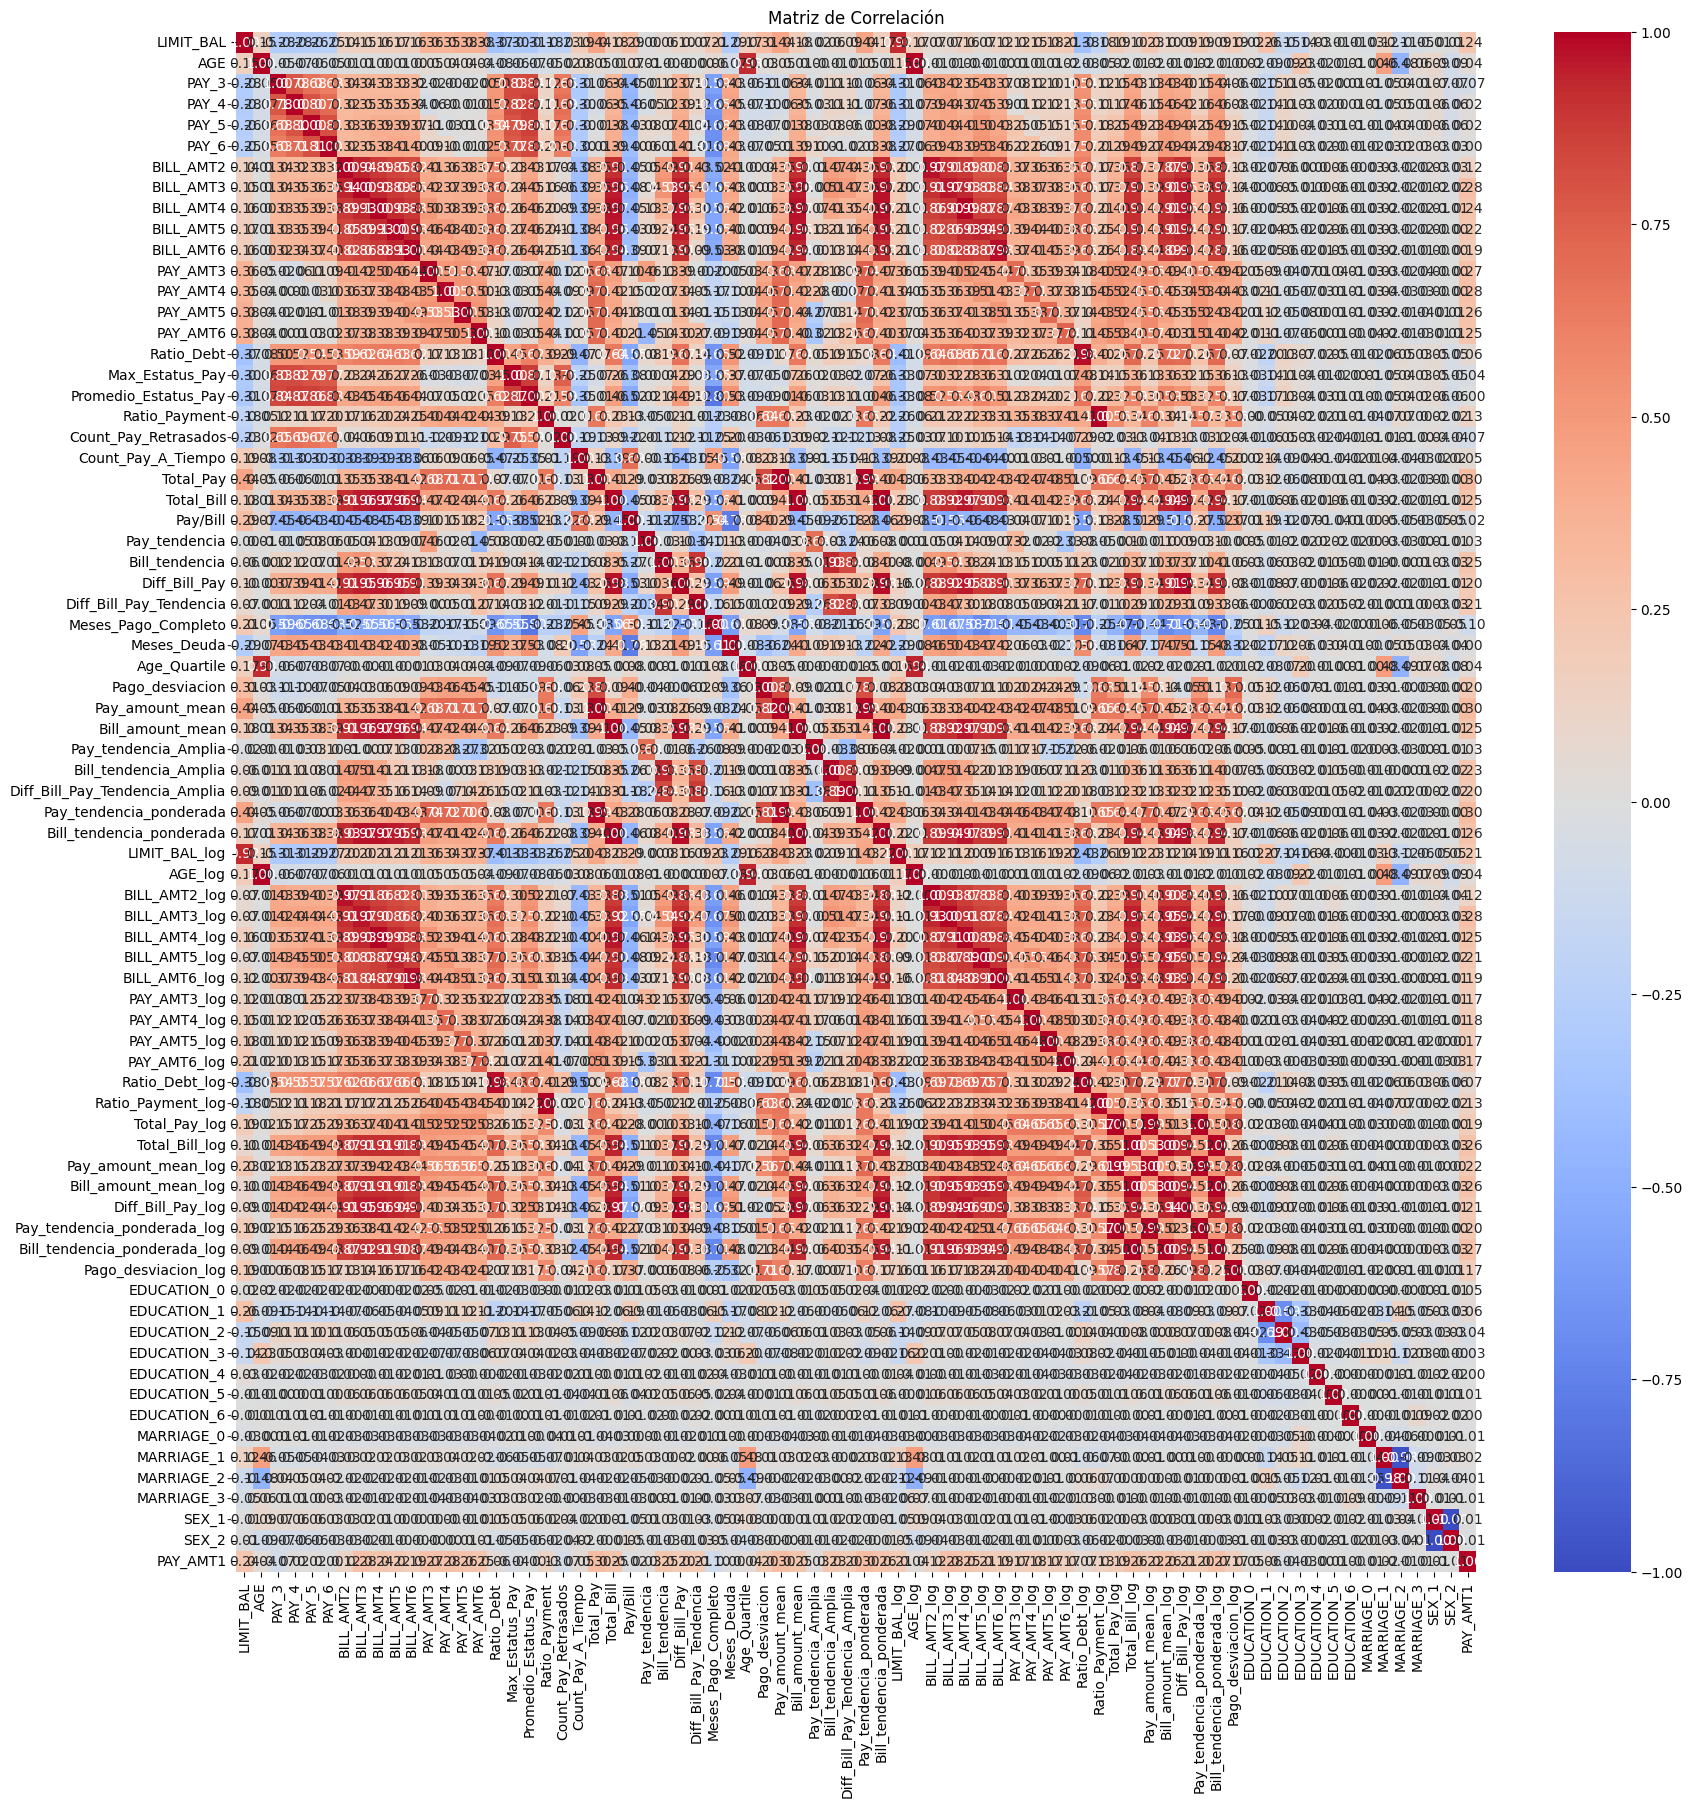

In [88]:
df_corr = df.copy()
df_corr['PAY_AMT1'] = y_train
correlation_matrix = df_corr.corr()
target_correlation = correlation_matrix["PAY_AMT1"].sort_values(ascending=False)
plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3937 entries, 1779 to 1922
Data columns (total 73 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   LIMIT_BAL                       3937 non-null   float64
 1   AGE                             3937 non-null   int64  
 2   PAY_3                           3937 non-null   int64  
 3   PAY_4                           3937 non-null   int64  
 4   PAY_5                           3937 non-null   int64  
 5   PAY_6                           3937 non-null   int64  
 6   BILL_AMT2                       3937 non-null   float64
 7   BILL_AMT3                       3937 non-null   float64
 8   BILL_AMT4                       3937 non-null   float64
 9   BILL_AMT5                       3937 non-null   float64
 10  BILL_AMT6                       3937 non-null   float64
 11  PAY_AMT3                        3937 non-null   float64
 12  PAY_AMT4                        3937

In [90]:
numeric_columns = df.select_dtypes(include = ['float64']).columns

In [91]:
numeric_columns

Index(['LIMIT_BAL', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5',
       'BILL_AMT6', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'Ratio_Debt', 'Promedio_Estatus_Pay', 'Ratio_Payment', 'Total_Pay',
       'Total_Bill', 'Pay/Bill', 'Pay_tendencia', 'Bill_tendencia',
       'Diff_Bill_Pay', 'Diff_Bill_Pay_Tendencia', 'Pago_desviacion',
       'Pay_amount_mean', 'Bill_amount_mean', 'Pay_tendencia_Amplia',
       'Bill_tendencia_Amplia', 'Diff_Bill_Pay_Tendencia_Amplia',
       'Pay_tendencia_ponderada', 'Bill_tendencia_ponderada', 'LIMIT_BAL_log',
       'AGE_log', 'BILL_AMT2_log', 'BILL_AMT3_log', 'BILL_AMT4_log',
       'BILL_AMT5_log', 'BILL_AMT6_log', 'PAY_AMT3_log', 'PAY_AMT4_log',
       'PAY_AMT5_log', 'PAY_AMT6_log', 'Ratio_Debt_log', 'Ratio_Payment_log',
       'Total_Pay_log', 'Total_Bill_log', 'Pay_amount_mean_log',
       'Bill_amount_mean_log', 'Diff_Bill_Pay_log',
       'Pay_tendencia_ponderada_log', 'Bill_tendencia_ponderada_log',
       'Pago_desviacion_l

In [92]:
len(numeric_columns)

49

In [93]:
numeric_columns

Index(['LIMIT_BAL', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5',
       'BILL_AMT6', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'Ratio_Debt', 'Promedio_Estatus_Pay', 'Ratio_Payment', 'Total_Pay',
       'Total_Bill', 'Pay/Bill', 'Pay_tendencia', 'Bill_tendencia',
       'Diff_Bill_Pay', 'Diff_Bill_Pay_Tendencia', 'Pago_desviacion',
       'Pay_amount_mean', 'Bill_amount_mean', 'Pay_tendencia_Amplia',
       'Bill_tendencia_Amplia', 'Diff_Bill_Pay_Tendencia_Amplia',
       'Pay_tendencia_ponderada', 'Bill_tendencia_ponderada', 'LIMIT_BAL_log',
       'AGE_log', 'BILL_AMT2_log', 'BILL_AMT3_log', 'BILL_AMT4_log',
       'BILL_AMT5_log', 'BILL_AMT6_log', 'PAY_AMT3_log', 'PAY_AMT4_log',
       'PAY_AMT5_log', 'PAY_AMT6_log', 'Ratio_Debt_log', 'Ratio_Payment_log',
       'Total_Pay_log', 'Total_Bill_log', 'Pay_amount_mean_log',
       'Bill_amount_mean_log', 'Diff_Bill_Pay_log',
       'Pay_tendencia_ponderada_log', 'Bill_tendencia_ponderada_log',
       'Pago_desviacion_l

In [94]:
categorical_columns = df.select_dtypes(exclude = ['float64']).columns

In [95]:
len(categorical_columns)

24

In [96]:
var_columns = list(categorical_columns) + list(numeric_columns)

In [97]:
var_columns

['AGE',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'Max_Estatus_Pay',
 'Count_Pay_Retrasados',
 'Count_Pay_A_Tiempo',
 'Meses_Pago_Completo',
 'Meses_Deuda',
 'Age_Quartile',
 'EDUCATION_0',
 'EDUCATION_1',
 'EDUCATION_2',
 'EDUCATION_3',
 'EDUCATION_4',
 'EDUCATION_5',
 'EDUCATION_6',
 'MARRIAGE_0',
 'MARRIAGE_1',
 'MARRIAGE_2',
 'MARRIAGE_3',
 'SEX_1',
 'SEX_2',
 'LIMIT_BAL',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'Ratio_Debt',
 'Promedio_Estatus_Pay',
 'Ratio_Payment',
 'Total_Pay',
 'Total_Bill',
 'Pay/Bill',
 'Pay_tendencia',
 'Bill_tendencia',
 'Diff_Bill_Pay',
 'Diff_Bill_Pay_Tendencia',
 'Pago_desviacion',
 'Pay_amount_mean',
 'Bill_amount_mean',
 'Pay_tendencia_Amplia',
 'Bill_tendencia_Amplia',
 'Diff_Bill_Pay_Tendencia_Amplia',
 'Pay_tendencia_ponderada',
 'Bill_tendencia_ponderada',
 'LIMIT_BAL_log',
 'AGE_log',
 'BILL_AMT2_log',
 'BILL_AMT3_log',
 'BILL_AMT4_log',
 'BILL_AMT5_log',
 'BILL_AMT

In [98]:
df[numeric_columns]

,LIMIT_BAL,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Promedio_Estatus_Pay,Ratio_Payment,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada,LIMIT_BAL_log,AGE_log,BILL_AMT2_log,BILL_AMT3_log,BILL_AMT4_log,BILL_AMT5_log,BILL_AMT6_log,PAY_AMT3_log,PAY_AMT4_log,PAY_AMT5_log,PAY_AMT6_log,Ratio_Debt_log,Ratio_Payment_log,Total_Pay_log,Total_Bill_log,Pay_amount_mean_log,Bill_amount_mean_log,Diff_Bill_Pay_log,Pay_tendencia_ponderada_log,Bill_tendencia_ponderada_log,Pago_desviacion_log
1779,130000.0,106130.0,66523.0,55678.0,20290.0,14802.0,1702.0,602.0,492.0,515.0,1.209946,0.00,0.025469,3311.0,157293.0,0.021050,1187.0,51721.0,153982.0,50534.0,584.755433,827.75,39323.25,648.5,39888.0,42906.0,2680.45,127116.40,11.849412,4.158883,11.727569,11.308640,11.827838,10.175497,10.495930,7.440734,6.403574,6.202536,6.248043,1.195393,0.705801,8.105609,12.090521,6.721124,10.704261,12.812534,7.894486,11.858742,6.374608
1070,50000.0,20439.0,20691.0,17081.0,16234.0,16330.0,1206.0,1000.0,697.0,532.0,1.406720,0.00,0.068700,3435.0,70336.0,0.048837,674.0,4361.0,66901.0,3687.0,301.917621,858.75,17584.00,488.5,2604.0,2115.5,2613.60,50590.65,11.002133,4.290459,10.551925,10.482654,11.496969,10.007667,10.537309,7.096721,6.909753,6.549651,6.280396,1.253228,0.726920,8.142354,11.421008,6.757804,10.034779,12.541491,7.869249,11.078886,5.716757
3385,260000.0,135476.0,127074.0,14.0,109293.0,107209.0,0.0,10000.0,6000.0,6500.0,1.461708,0.00,0.299755,47119.0,380044.0,0.360429,-6500.0,-1389.0,243065.0,5111.0,10787.209633,11779.75,95011.00,10109.5,-11260.0,-14143.5,32205.10,259588.65,12.506185,4.143135,12.259476,11.864103,11.306516,11.778784,11.917250,0.693147,9.816294,8.699848,8.779865,1.268810,0.832802,11.249936,12.901532,10.441347,11.515253,13.029961,10.913305,12.520104,10.077335
2705,320000.0,110045.0,112393.0,111541.0,109293.0,107209.0,5000.0,5000.0,5000.0,5000.0,1.428425,0.00,0.062500,20000.0,457096.0,0.043754,0.0,-5835.0,428103.0,-5835.0,0.000000,5000.00,114274.00,0.0,-4614.0,-4614.0,14000.00,318211.75,12.706854,4.189655,11.758668,11.755032,12.169808,11.702686,11.846493,8.517593,8.517593,8.517593,8.517593,1.259408,0.723919,9.903588,13.077320,8.517593,11.691038,13.384574,9.546955,12.714124,0.693147
4025,120000.0,24067.0,24372.0,24670.0,25617.0,26535.0,1000.0,1500.0,1500.0,1500.0,0.843283,0.50,0.045833,5500.0,101194.0,0.054351,-500.0,-2163.0,95694.0,-1663.0,250.000000,1375.00,25298.50,-250.0,-1555.0,-1305.0,3700.00,70185.45,11.775305,4.127134,10.642540,10.580810,11.571251,10.360248,10.776892,6.909753,7.314553,7.314553,7.314553,1.077795,0.715805,8.612867,11.712399,7.227662,10.326154,12.639471,8.216628,11.343127,5.529429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,50000.0,14446.0,10339.0,10766.0,10945.0,11214.0,600.0,500.0,600.0,500.0,0.865280,0.00,0.044000,2200.0,43264.0,0.050851,100.0,-875.0,41064.0,-975.0,57.735027,550.00,10816.00,0.0,-527.0,-527.0,1560.00,30026.80,11.002133,4.158883,10.381521,10.140100,11.430652,9.735483,10.391454,6.400257,6.218600,6.400257,6.218600,1.085253,0.714909,7.697121,11.068917,6.313548,9.682716,12.444570,7.353722,10.697041,4.089919
70,50000.0,36927.0,34929.0,31874.0,28993.0,29409.0,1505.0,1001.0,2007.0,2007.0,2.504100,0.00,0.130400,6520.0,125205.0,0.052075,-502.0,5520.0,118685.0,6022.0,481.499048,1630.00,31301.25,-754.0,4200.5,4954.5,4363.10,89464.35,11.002133,4.330733,10.910332,10.818357,11.637000,10.461817,10.835159,7.317876,6.910751,7.605392,7.605392,1.525841,0.756310,8.782936,11.891958,7.397562,10.505704,12.711350,8.381396,11.548894,6.181049
2878,220000.0,135476.0,131412.0,117308.0,109293.0,107209.0,5000.0,5000.0

In [99]:
sc = StandardScaler()
df[numeric_columns] = sc.fit_transform(df[numeric_columns])

In [100]:
df[numeric_columns].describe()

,LIMIT_BAL,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Promedio_Estatus_Pay,Ratio_Payment,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada,LIMIT_BAL_log,AGE_log,BILL_AMT2_log,BILL_AMT3_log,BILL_AMT4_log,BILL_AMT5_log,BILL_AMT6_log,PAY_AMT3_log,PAY_AMT4_log,PAY_AMT5_log,PAY_AMT6_log,Ratio_Debt_log,Ratio_Payment_log,Total_Pay_log,Total_Bill_log,Pay_amount_mean_log,Bill_amount_mean_log,Diff_Bill_Pay_log,Pay_tendencia_ponderada_log,Bill_tendencia_ponderada_log,Pago_desviacion_log
count,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03
mean,8.031281e-17,-1.055798e-16,-6.767933e-17,-5.414346e-17,-4.150999e-17,-2.346217e-17,-1.443826e-17,-5.143629e-17,7.219129e-18,1.443826e-17,-7.309368e-17,2.842532e-17,-1.687471e-16,4.376597e-17,3.699803e-17,-1.335539e-16,4.241238e-17,2.797412e-17,3.248608e-17,-1.082869e-17,-6.136259e-17,4.376597e-17,3.699803e-17,-1.488945e-17,1.443826e-17,-1.940141e-17,5.685064e-17,5.233868e-17,8.031281e-16,-2.790193e-15,1.446984e-15,5.470746e-16,-2.874116e-15,1.176267e-15,-6.853660e-16,-1.773198e-16,4.963151e-17,1.317491e-16,7.760563e-17,5.459466e-17,8.211759e-16,1.696495e-16,-2.792900e-16,4.692434e-17,-1.523687e-15,-4.836816e-16,1.606256e-16,-6.779213e-16,-2.544743e-16
std,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00
min,-1.231616e+00,-1.289837e+00,-1.222655e+00,-2.946712e+00,-1.033079e+00,-1.447768e+00,-9.220493e-01,-8.828383e-01,-8.849074e-01,-8.998548e-01,-1.043887e+00,-1.927177e+00,-1.180725e+00,-9.773466e-01,-1.039894e+00,-8.169880e-01,-2.619138e+00,-1.304090e+00,-2.264032e+00,-1.532812e+00,-7.545150e-01,-9.773466e-01,-1.039894e+00,-2.629665e+00,-1.306178e+00,-1.419862e+00,-9.901546e-01,-1.036275e+00,-2.325757e+00,-1.780479e+00,-1.171587e+00,-1.173852e+00,-9.315430e-01,-1.266517e+00,-1.047581e+00,-1.885263e+00,-1.796179e+00,-1.776483e+00,-1.722686e+00,-1.235751e+00,-1.210947e+00,-3.153561e+00,-1.330228e+00,-2.980313e+00,-1.330177e+00,-9.397871e-01,-3.128256e+00,-1.340934e+00,-2.430153e+00
25%,-8.499712e-01,-8.308220e-01,-8.175095e-01,-8.168342e-01,-8.226916e-01,-8.155267e-01,-8.001749e-01,-7.859645e-01,-7.859752e-01,-8.207755e-01,-9.139658e-01,-7.632581e-01,-8.100327e-01,-7.382648e-01,-8.116950e-01,-7.222450e-01,-2.126704e-01,-5.250698e-01,-7.964665e-01,-5.020286e-01,-6.604670e-01,-7.382648e-01,-8.116950e-01,-1.652455e-01,-5.104264e-01,-4.939086e-01,-7.382360e-01,-8.153370e-01,-7.992979e-01,-8.102174e-01,-9.816146e-01,-9.772953e-01,-8.537461e-01,-1.032326e+00,-9.567716e-01,-1.361665e-01,-1.584136e-01,-1.453111e-01,-2.246499e-01,-1.008196e+00,-8.169837e-01,-1.518949e-01,-9.511333e-01,-

In [101]:
X_test[numeric_columns] = sc.transform(X_test[numeric_columns])

In [102]:
X_test[numeric_columns].describe()

,LIMIT_BAL,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Promedio_Estatus_Pay,Ratio_Payment,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada,LIMIT_BAL_log,AGE_log,BILL_AMT2_log,BILL_AMT3_log,BILL_AMT4_log,BILL_AMT5_log,BILL_AMT6_log,PAY_AMT3_log,PAY_AMT4_log,PAY_AMT5_log,PAY_AMT6_log,Ratio_Debt_log,Ratio_Payment_log,Total_Pay_log,Total_Bill_log,Pay_amount_mean_log,Bill_amount_mean_log,Diff_Bill_Pay_log,Pay_tendencia_ponderada_log,Bill_tendencia_ponderada_log,Pago_desviacion_log
count,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000
mean,-0.008770,0.222627,0.230121,0.257074,0.270769,0.249177,0.708528,0.764133,0.682216,1.024347,0.020847,0.122437,0.458589,0.471561,0.246776,-0.648864,-0.181128,0.077770,0.241302,0.086555,0.745962,0.471561,0.246776,-0.053256,0.056466,0.030068,0.476999,0.248337,-0.022610,0.034662,0.012486,0.038220,0.069314,0.035385,0.037817,0.033377,0.032608,0.011298,-0.022477,0.023077,0.378771,0.015633,0.015640,0.006891,0.015642,0.039748,0.015636,0.015560,0.034023
std,1.011861,1.702482,1.688877,1.729890,1.760423,1.722720,4.570143,5.628253,4.088156,6.590241,0.989792,1.214371,2.497723,2.825660,1.715680,44.469139,5.498209,2.085812,1.692650,2.326306,4.086132,2.825660,1.715680,3.769229,1.964758,2.235377,2.863446,1.720513,1.020795,0.995996,1.114390,1.052555,1.128416,1.091668,1.077088,1.021437,1.011780,1.028500,1.025156,1.001249,2.100009,1.031234,1.015554,1.016873,1.015553,1.139405,1.031877,1.015693,1.022980
min,-1.231616,-1.404109,-0.985509,-0.937763,-1.396009,-1.068573,-0.922049,-0.882838,-0.884907,-0.899855,-1.164766,-1.927177,-1.180725,-0.977347,-0.936910,-1783.028721,-68.488859,-9.330540,-1.964592,-13.934935,-0.754515,-0.977347,-0.936910,-34.640614,-11.892238,-16.373973,-0.990155,-0.936836,-2.325757,-1.780479,-13.589790,-1.621587,-1.023900,-9.306609,-1.714393,-1.885263,-1.796179,-1.776483,-1.722686,-1.466935,-1.210947,-3.153561,-1.664028,-2.980313,-1.663895,-4.596597,-3.128256,-1.660693,-2.430153
25%,-0.926300,-0.829546,-0.817618,-0.811811,-0.816197,-0.813460,-0.768769,-0.779190,-0.807891,-0.862309,-0.904866,-0.763258,-0.797628,-0.727518,-0.796130,-0.721616,-0.184543,-0.530315,-0.793412,-0.505749,-0.653715,-0.727518,-0.796130,-0.158928,-0.522659,-0.505362,-0.727512,-0.802724,-0.987131,-0.682602,-0.978094,-0.977619,-0.846889,-1.004219,-0.951935,-0.060538,-0.136640,-0.225326,-0.455003,-0.992978,-0.803914,-0.134242,-0.892013,-0.209106,-0.892023,-0.873665,-0.140645,-0.905896,-0.293898
50%,-0.239340,-0.448479,-0.421265,-0.388408,-0.379572,-0.384532,-0.340958,-0.348942,-0.351738,-0.401124,-0.288432,0.400661,-0.195618,-0.385219,-0.397847,-0.640386,-0.038433,-0.413912,-0.383888,-0.363866,-0.452226,-0.385219,-0.397847,-0.017329,-0.393376,-0.372130,-0.383462,-0.395798,0.129385,-0.079244,-0.212883,-0.156675,-0.320226,0.015768,-0.186402,0.380086,0.393082,0.395077,0.349401,-0.126443,-0.178224,0.212286,-0.024228,0.180346,-0.024265,-0.298993,0.207103,-0.014043,0.159063
75%,0.523950,0.534386,0.516132,0.552339,0.507312,0.488488,0.500288,0.519963,0.485116,0.554058,0.822724,0.400661,0.473380,0.451023,0.519339,0.699127,0.287764,0.142736,0.512341,0.204972,0.280067,0.451023,0.519339,0.223375,0.144832,0.137783,0.454808,0.544462,0.751841,0.783894,

In [103]:

X_test.isnull().sum().sum()

np.int64(0)

In [104]:
X_test.isnull().sum().sum()

np.int64(0)

In [105]:
df[categorical_columns]

,AGE,PAY_3,PAY_4,PAY_5,PAY_6,Max_Estatus_Pay,Count_Pay_Retrasados,Count_Pay_A_Tiempo,Meses_Pago_Completo,Meses_Deuda,Age_Quartile,EDUCATION_0,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6,MARRIAGE_0,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3,SEX_1,SEX_2
1779,41,0,0,0,0,0,0,0,0,4,3,False,False,True,False,False,False,False,False,False,True,False,True,False
1070,50,0,0,0,0,0,0,0,0,4,4,False,False,True,False,False,False,False,False,True,False,False,False,True
3385,40,0,0,0,0,0,0,0,1,3,3,False,False,True,False,False,False,False,False,False,True,False,False,True
2705,43,0,0,0,0,0,0,0,0,4,4,False,True,False,False,False,False,False,False,True,False,False,True,False
4025,39,2,0,0,0,2,1,0,0,4,3,False,False,True,False,False,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,41,0,0,0,0,0,0,0,0,4,3,False,False,False,True,False,False,False,False,False,True,False,True,False
70,53,0,0,0,0,0,0,0,0,4,4,False,False,True,False,False,False,False,False,True,False,False,False,True
2878,34,0,0,0,0,0,0,0,0,4,2,False,False,True,False,False,False,False,False,True,False,False,True,False
1950,28,0,0,0,0,0,0,0,0,4,1,False,True,False,False,False,False,False,False,False,True,False,False,True


In [106]:
df[var_columns]

,AGE,PAY_3,PAY_4,PAY_5,PAY_6,Max_Estatus_Pay,Count_Pay_Retrasados,Count_Pay_A_Tiempo,Meses_Pago_Completo,Meses_Deuda,Age_Quartile,EDUCATION_0,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6,MARRIAGE_0,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3,SEX_1,SEX_2,LIMIT_BAL,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Promedio_Estatus_Pay,Ratio_Payment,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada,LIMIT_BAL_log,AGE_log,BILL_AMT2_log,BILL_AMT3_log,BILL_AMT4_log,BILL_AMT5_log,BILL_AMT6_log,PAY_AMT3_log,PAY_AMT4_log,PAY_AMT5_log,PAY_AMT6_log,Ratio_Debt_log,Ratio_Payment_log,Total_Pay_log,Total_Bill_log,Pay_amount_mean_log,Bill_amount_mean_log,Diff_Bill_Pay_log,Pay_tendencia_ponderada_log,Bill_tendencia_ponderada_log,Pago_desviacion_log
1779,41,0,0,0,0,0,0,0,0,4,3,False,False,True,False,False,False,False,False,False,True,False,True,False,-0.315669,1.460216,0.647552,0.546577,-0.313795,-0.441092,-0.390177,-0.695321,-0.730874,-0.728738,-0.114373,0.400661,-0.901948,-0.752140,0.137226,-0.762892,0.257024,2.542513,0.250964,2.152931,-0.584582,-0.752140,0.137226,0.142545,2.800068,2.715506,-0.724306,0.273852,0.045315,0.682001,1.289744,0.862927,0.586543,0.104459,-0.267415,0.350797,0.054649,-0.003563,0.015476,0.073840,-0.914054,-0.175899,0.518932,-0.255893,0.518910,0.381551,-0.135606,0.618664,-0.078705
1070,50,0,0,0,0,0,0,0,0,4,4,False,False,True,False,False,False,False,False,True,False,False,False,True,-0.926300,-0.441146,-0.403899,-0.437501,-0.424934,-0.398560,-0.545176,-0.571347,-0.666693,-0.723089,0.025798,0.400661,-0.428760,-0.743706,-0.437265,-0.691483,0.129333,-0.172507,-0.346141,-0.194733,-0.666776,-0.743706,-0.437265,0.103100,-0.193153,-0.241290,-0.730936,-0.435629,-0.987131,1.546719,-0.201873,-0.130881,-0.376628,-0.050763,-0.206085,0.236796,0.218709,0.108138,0.025599,0.224644,-0.418561,-0.161138,-0.081002,-0.239315,-0.081039,-0.252493,-0.146094,-0.070807,-0.350977
3385,40,0,0,0,0,0,0,0,1,3,3,False,False,True,False,False,False,False,False,False,True,False,False,True,0.676607,2.111363,2.036677,-0.872645,2.125003,2.131045,-0.922049,2.232076,0.993552,1.259874,0.064969,0.400661,2.100279,2.227575,1.608855,0.109272,-1.656352,-0.502139,0.861796,-0.123371,2.380307,2.227575,1.608855,2.474948,-1.306178,-1.419862,2.203965,1.502020,0.845621,0.578503,1.964609,1.531247,-0.931042,1.587299,1.839197,-1.885263,1.160759,0.800071,0.807699,0.265272,2.065640,1.087209,1.245658,1.425508,1.245673,0.890173,1.118920,1.203374,1.453783
2705,43,0,0,0,0,0,0,0,0,4,4,False,True,False,False,False,False,False,False,True,False,False,True,False,1.134581,1.547085,1.699874,1.970872,2.125003,2.131045,0.640444,0.674619,0.680475,0.761475,0.041260,0.400661,-0.496623,0.383006,2.117907,-0.704544,-0.038433,-0.757016,2.130580,-0.671913,-0.754515,0.383006,2.117907,-0.017329,-0.772626,-0.729094,0.398373,2.045522,1.090146,0.884232,1.329201,1.400015,1.582027,1.516918,1.734325,0.707654,0.739832,0.741421,0.725632,0.240757,-0.488983,0.546367,1.403178,0.556043,1.403201,1.719711,0.551108,1.374906,-2.430153
4025,39,2,0,0,0,2,1,0,0,4,3,False,False,True,False,False,False,False,False,False,True,False,False,True,-0.391998,-0.360646,-0.319451,-0.244010,-0.167828,-0.114506,-0.609551,-0.415601,-0.415293,-0.401456,-0.375566,0.982620,-0.679050,-0.603250,-0.233399,-0.677312,-0.162888,-0.546510,-0.148710,-0.462840,-0.681864,-0.603250,-0.233399,-0.078961,-0.527045,-0.489233,-0.623187,-0.253963,-0.044988,0.473349,-0.086904,-0.012781,-0.160391,0.275330,0.149013,0.174837,0.349910,0.354283,0.349193,-0.232794,-0.679345,0.027872,0.180106,-0.026957,0.180073,-0.023291,-0.001734,0.162808,-0.428508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

## Entrenamiento

In [107]:
model_Regression = LinearRegression() 

In [108]:
y_train

1779     2781.0
1070     1306.0
3385     6500.0
2705     4000.0
4025     1000.0
         ...   
1993     1500.0
70       2010.0
2878     4700.0
1950    13000.0
1922        0.0
Name: PAY_AMT2, Length: 3937, dtype: float64

In [109]:
model_Regression.fit(df[var_columns],y_train)

LinearRegression()

In [110]:
model_RandFor = RandomForestRegressor()

In [111]:
model_RandFor.fit(df[var_columns],y_train)

RandomForestRegressor()

In [112]:
cv_scores = cross_val_score(model_Regression,df[var_columns],y_train, cv=5, scoring='r2')

In [113]:
print(cv_scores)
print("r2: %0.2f (+/- %0.2f)" % (cv_scores.mean(), cv_scores.std() * 2))

[0.35230409 0.42213792 0.32681545 0.40705931 0.38428138]
r2: 0.38 (+/- 0.07)


In [114]:
y_pred = model_Regression.predict(X_test[var_columns])
r2 = r2_score(y_test, y_pred)
print(f"r2 de Regresion lineal con conunto de prueba: {r2}")

r2 de Regresion lineal con conunto de prueba: -54.638530008842444


In [115]:
cv_scores_RandFor = cross_val_score(model_RandFor, df[var_columns],y_train, cv=5, scoring='r2')

In [116]:
print(cv_scores_RandFor)
print("r2: %0.2f (+/- %0.2f)" % (cv_scores_RandFor.mean(), cv_scores_RandFor.std() * 2))

[0.55084009 0.65015582 0.58601626 0.59746698 0.64175759]
r2: 0.61 (+/- 0.07)


In [117]:
y_pred = model_RandFor.predict(X_test[var_columns])
r2 = r2_score(y_test, y_pred)
print(f"r2 de Regresion lineal con conunto de prueba: {r2}")

r2 de Regresion lineal con conunto de prueba: 0.5958810875991676


In [118]:
xgb_r = XGBRegressor(enable_categorical=True, tree_method='hist')

In [119]:
xgb_r.fit(df[var_columns],y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [120]:
cv_scores_xgb_r = cross_val_score(xgb_r,df[var_columns],y_train, cv=5, scoring = 'r2')

In [121]:
print(cv_scores_xgb_r)
print("r2: %0.2f (+/- %0.2f)" % (cv_scores_xgb_r.mean(), cv_scores_xgb_r.std() * 2))

[0.52268587 0.65931053 0.66002422 0.61679513 0.62389617]
r2: 0.62 (+/- 0.10)


In [122]:
y_pred = xgb_r.predict(X_test[var_columns])
r2 = r2_score(y_test, y_pred)
print(f"R2 XGB: {r2}")

R2 XGB: 0.6448272969187874


### Modelo con SelectKbest

In [204]:
selector = SelectKBest(score_func = f_regression, k = 55)

X_train_selected = selector.fit_transform(df[var_columns],y_train)
X_test_selected = selector.transform(X_test[var_columns])

In [205]:
model_k_best = LinearRegression()# Marcaba error de que el modelo no convergia 

In [206]:
model_k_best.fit(X_train_selected, y_train)

LinearRegression()

In [207]:
cv_scores_kbest = cross_val_score(model_k_best, X_train_selected, y_train, cv=5, scoring='r2')

In [208]:
print(cv_scores_kbest)
print("r2: %0.2f (+/- %0.2f)" % (cv_scores_kbest.mean(), cv_scores_kbest.std() * 2))

[0.3454467  0.40943647 0.31904241 0.40220597 0.38913625]
r2: 0.37 (+/- 0.07)


In [209]:
y_pred = model_k_best.predict(X_test_selected)
r2 = r2_score(y_test, y_pred)
print(f"R2 SelectKbeast con conjunto de prueba: {r2}")

R2 SelectKbeast con conjunto de prueba: -0.2694151829253022


In [210]:
model_RF_k_best = RandomForestRegressor()

In [211]:
model_RF_k_best.fit(X_train_selected,y_train)

RandomForestRegressor()

In [212]:
cv_scores_RF_k_best = cross_val_score(model_RF_k_best, X_train_selected, y_train, cv=5, scoring = 'r2')

In [213]:
print(cv_scores_RF_k_best)
print("r2: %0.2f (+/- %0.2f)" % (cv_scores_RF_k_best.mean(), cv_scores_RF_k_best.std() * 2))

[0.50827604 0.64316564 0.58912399 0.55581433 0.65979   ]
r2: 0.59 (+/- 0.11)


In [214]:
y_pred = model_RF_k_best.predict(X_test_selected)
r2 = r2_score(y_test, y_pred)
print(f"R2 Random Forest SelectKbeast con conjunto de prueba: {r2}")

R2 Random Forest SelectKbeast con conjunto de prueba: 0.6284747719673616


In [215]:
model_XGBr_k_best = XGBRegressor()

In [216]:
model_XGBr_k_best.fit(X_train_selected, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [217]:
cv_scores_XGBr_kbest = cross_val_score(model_XGBr_k_best, X_train_selected, y_train, cv=5, scoring='r2')

In [218]:
print(cv_scores_XGBr_kbest)
print("r2: %0.2f (+/- %0.2f)" % (cv_scores_XGBr_kbest.mean(), cv_scores_XGBr_kbest.std() * 2))

[0.50653626 0.67557377 0.66796176 0.69869056 0.63093817]
r2: 0.64 (+/- 0.14)


In [219]:
y_pred = model_XGBr_k_best.predict(X_test_selected)
r2 = r2_score(y_test, y_pred)
print(f"R2 SelectKbeast con conjunto de prueba: {r2}")

R2 SelectKbeast con conjunto de prueba: 0.6891582795204687
